# EDA - Student Performance Prediction

This notebook runs Exploratory Data Analysis (EDA) on the two UCI student-performance datasets:
- `mat2.csv` (Mathematics): 395 x 34
- `por2.csv` (Portuguese): 649 x 34

**Step 1 : load both datasets and remove unnecessary columns**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

%matplotlib inline

sns.set_theme(style='whitegrid')
sns.set_context('notebook', font_scale=1.35)
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'legend.frameon': True,
    'figure.titlesize': 16,
})


def style_ax(ax, xlabel, ylabel, title=None, rot_xticks=0):
    ax.set_xlabel(xlabel, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
    if title:
        ax.set_title(title, fontsize=15, fontweight='bold', pad=12)
    if rot_xticks:
        plt.setp(ax.get_xticklabels(), rotation=rot_xticks, ha='right')
    ax.grid(True, which='major', alpha=0.35)
    return ax


### Load both datasets

In [9]:
mat_df = pd.read_csv('Student Performance Prediction Dataset/mat2.csv')
por_df = pd.read_csv('Student Performance Prediction Dataset/por2.csv')
print('mat2 shape :', mat_df.shape)
print('por2 shape :', por_df.shape)


mat2 shape : (395, 34)
por2 shape : (649, 34)


### Remove unnecessary columns

The `Unnamed: 0` column is just the auto-generated numeric row index - it carries no information, so it is dropped from both datasets.

In [10]:
cols_to_drop = ['Unnamed: 0']
mat_df = mat_df.drop(columns=[c for c in cols_to_drop if c in mat_df.columns])
por_df = por_df.drop(columns=[c for c in cols_to_drop if c in por_df.columns])
print('After drop -> mat_df:', mat_df.shape, '| por_df:', por_df.shape)


After drop -> mat_df: (395, 33) | por_df: (649, 33)


In [11]:
print('--- MAT ---')
print(mat_df.dtypes.to_string())
print('\n--- POR ---')
print(por_df.dtypes.to_string())
print('\nNulls: mat_df=', int(mat_df.isna().sum().sum()), '| por_df=', int(por_df.isna().sum().sum()))


--- MAT ---
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64

--- POR ---
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup      

In [12]:
mat_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [13]:
por_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


### Q1. Which address type (urban vs. rural) achieves better final grades?

Using an **empirical CDF (ECDF)** so we can see the *whole* grade distribution for urban vs rural students at every score, not just the middle.

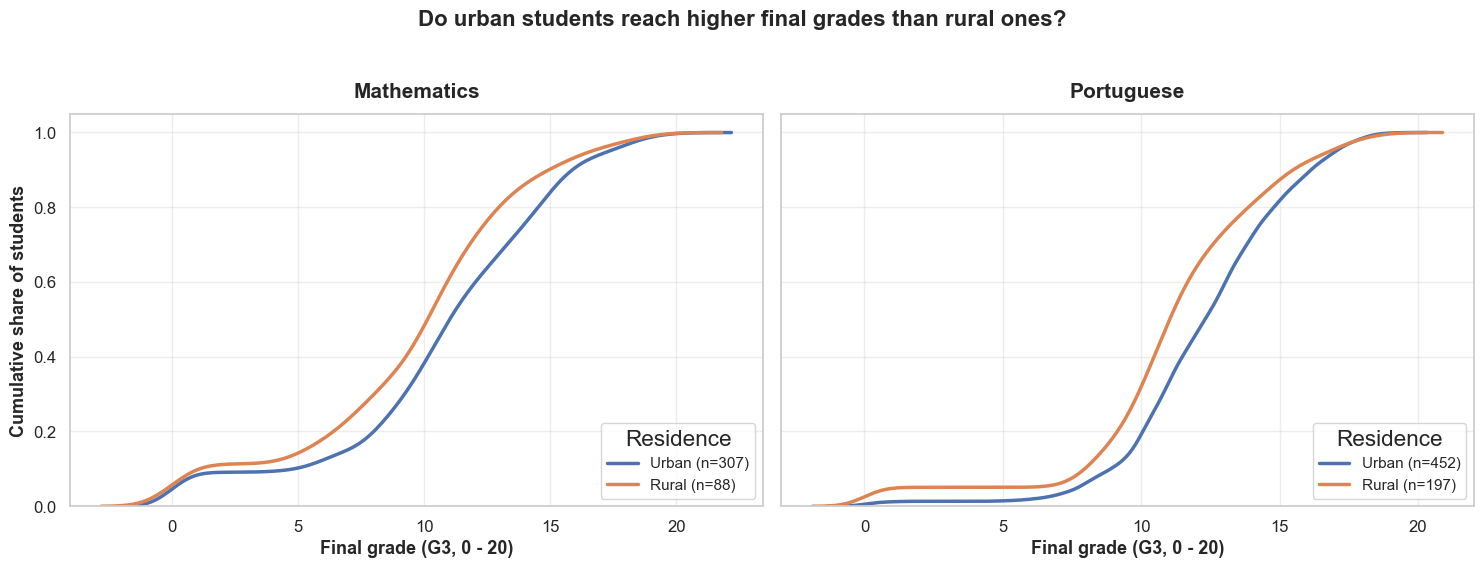

In [18]:
ADDR_LBL = {'U': 'Urban', 'R': 'Rural'}
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    for a in ('U', 'R'):
        sub = df.loc[df['address'] == a, 'G3']
        sns.kdeplot(sub, cumulative=True, bw_adjust=0.5, weights=None,
                    label=f"{ADDR_LBL[a]} (n={len(sub)})", ax=ax, lw=2.5)
    ax.legend(title='Residence', loc='lower right')
    ax.grid(True, alpha=0.35)
    ax.set_title(title, fontsize=15, fontweight='bold', pad=12)
    ax.set_xlabel('Final grade (G3, 0 - 20)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Cumulative share of students', fontsize=13, fontweight='bold')
fig.suptitle('Do urban students reach higher final grades than rural ones?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q2. Do parents' education levels influence the student's performance?

Education level is ordinal (0 = none .. 4 = higher), so a **line plot with a 95 % CI ribbon** shows the trend cleanly for both father and mother education.

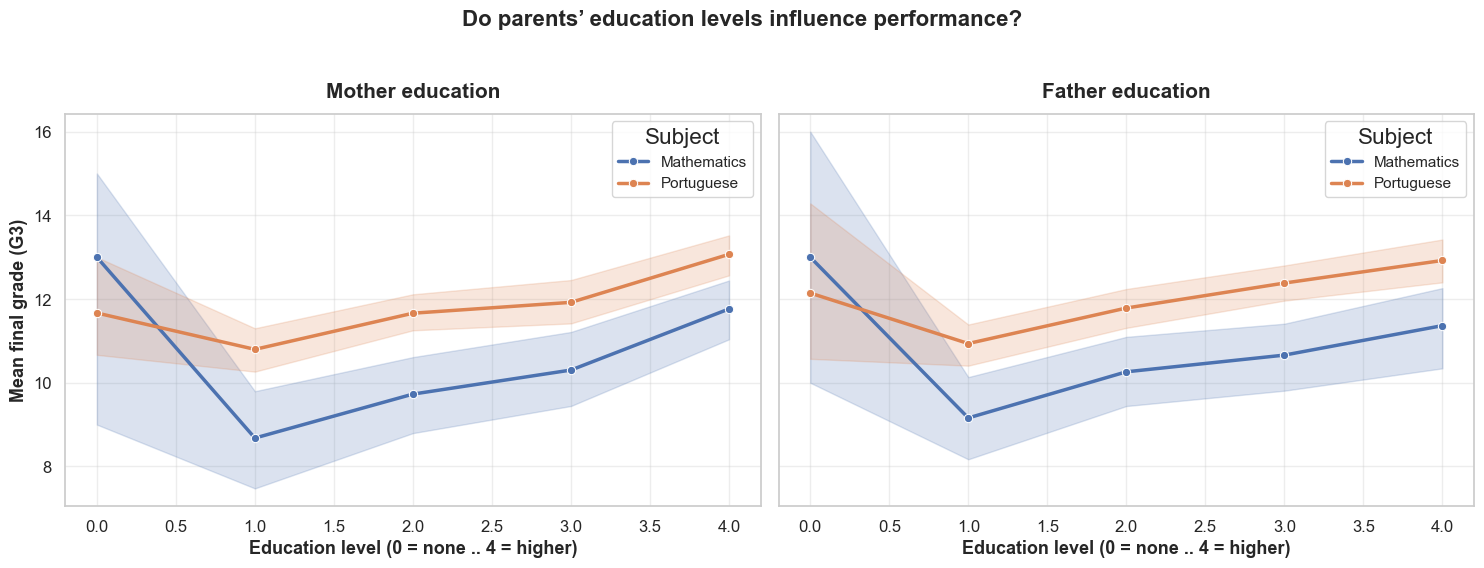

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, col, title in zip(axes, ('Medu', 'Fedu'), ('Mother education', 'Father education')):
    for df, name in ((mat_df, 'Mathematics'), (por_df, 'Portuguese')):
        sns.lineplot(data=df, x=col, y='G3', ax=ax, marker='o', lw=2.5,
                     errorbar=('ci', 95), label=name)
    style_ax(ax, 'Education level (0 = none .. 4 = higher)',
             'Mean final grade (G3)', title)
    ax.legend(title='Subject')
fig.suptitle('Do parents\u2019 education levels influence performance?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q3. How does weekend alcohol consumption relate to performance?

Weekend alcohol (Walc, 1..5) is ordinal with only five levels, so a **box plot** gives the full spread of grades at each level.

C:\Users\milon\AppData\Local\Temp\ipykernel_1600\1698767556.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Walc', y='G3', ax=ax, palette='Reds_r', width=0.55)
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\1698767556.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Walc', y='G3', ax=ax, palette='Reds_r', width=0.55)


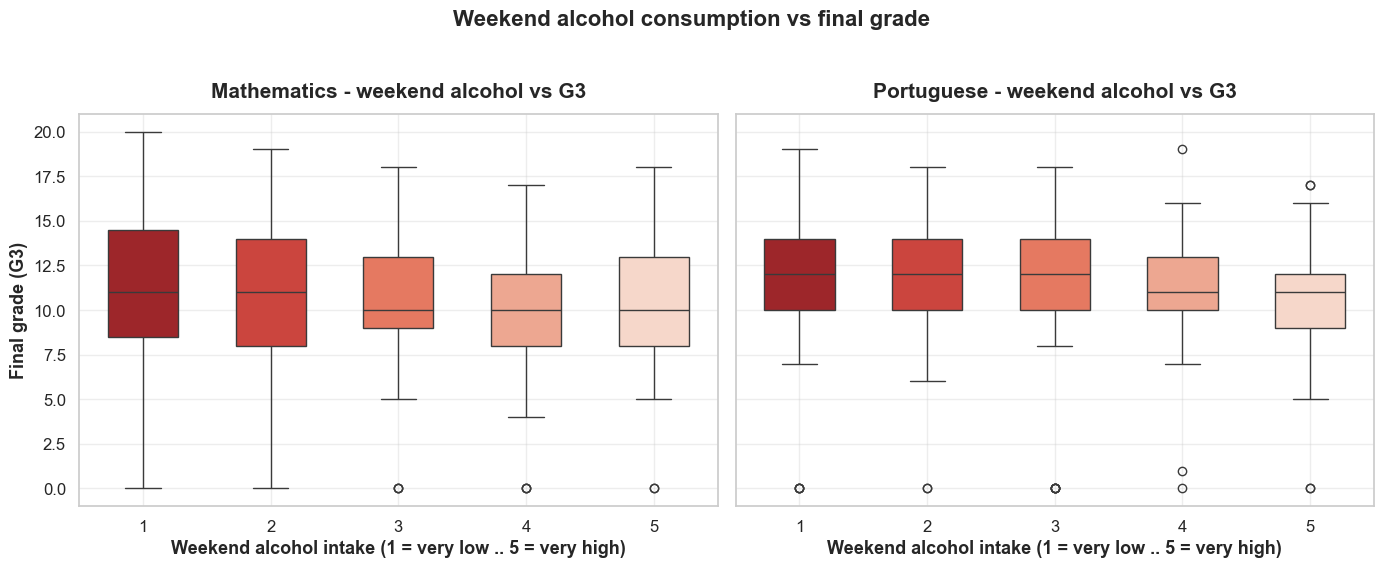

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.boxplot(data=df, x='Walc', y='G3', ax=ax, palette='Reds_r', width=0.55)
    style_ax(ax, 'Weekend alcohol intake (1 = very low .. 5 = very high)',
             'Final grade (G3)', f'{title} - weekend alcohol vs G3')
fig.suptitle('Weekend alcohol consumption vs final grade',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q4. Which separates students better - past failures or study time?

Two different idioms: a **letter-value (boxen) plot** for past failures (which has many outliers) and a **strip / beeswarm plot** for weekly study time, for both subjects.

C:\Users\milon\AppData\Local\Temp\ipykernel_1600\2840294457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='failures', y='G3', ax=axes[row, 0], palette='viridis')
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\2840294457.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='studytime', y='G3', ax=axes[row, 1],
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\2840294457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='failures', y='G3', ax=axes[row, 0], palette='viridis')
C:\Users\milon\AppData

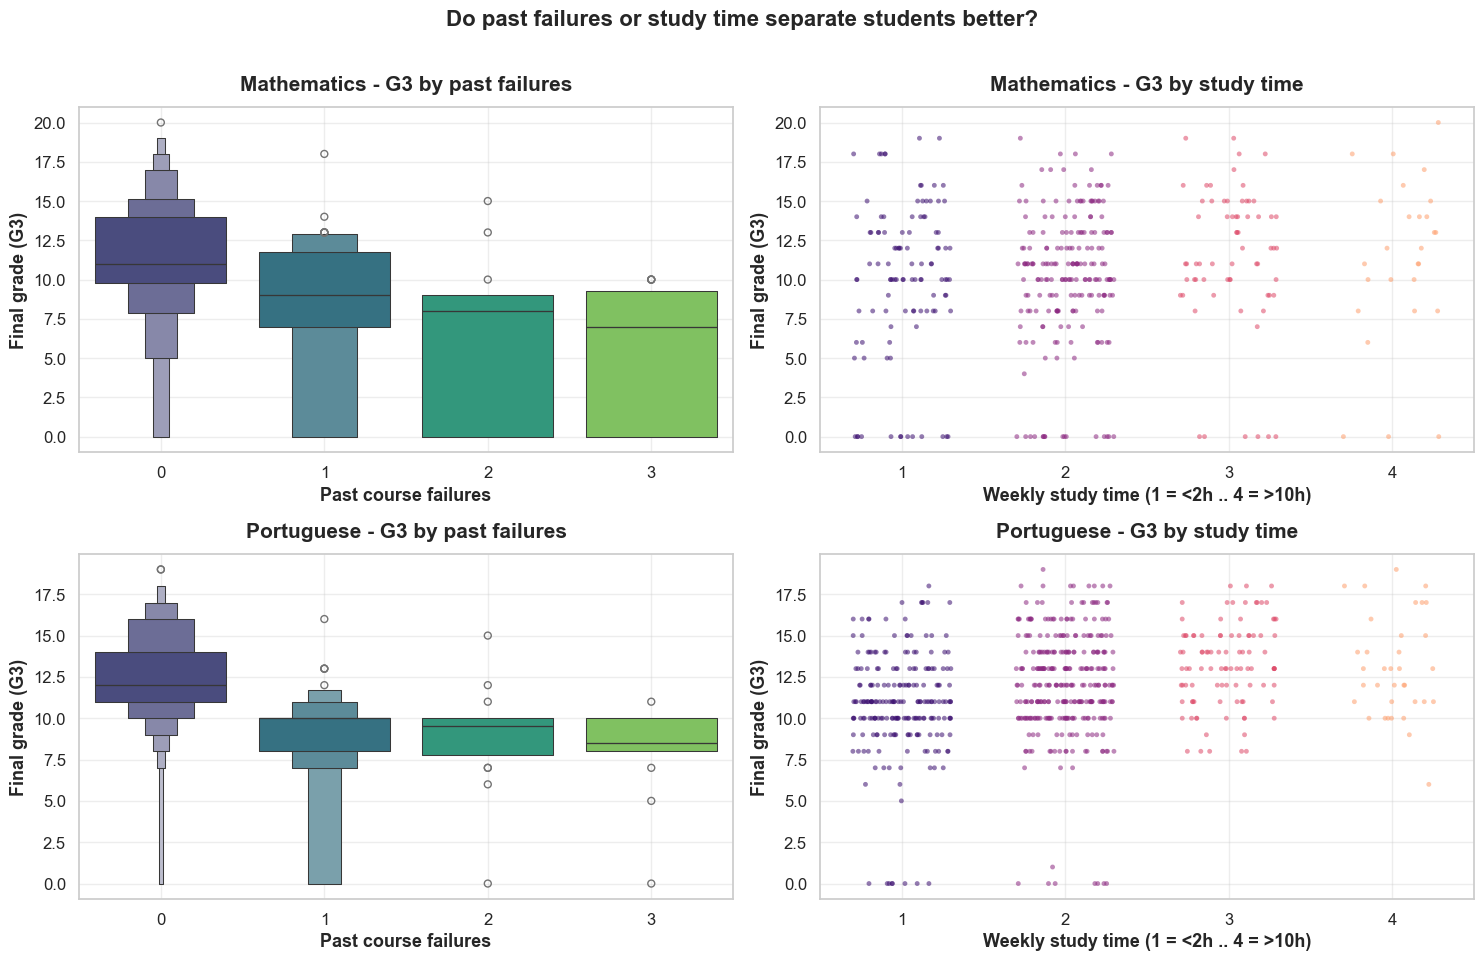

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9.5))
for row, (df, title) in enumerate(((mat_df, 'Mathematics'), (por_df, 'Portuguese'))):
    sns.boxenplot(data=df, x='failures', y='G3', ax=axes[row, 0], palette='viridis')
    style_ax(axes[row, 0], 'Past course failures', 'Final grade (G3)',
             f'{title} - G3 by past failures')
    sns.stripplot(data=df, x='studytime', y='G3', ax=axes[row, 1],
                  palette='magma', jitter=0.3, alpha=0.55, size=3.5)
    style_ax(axes[row, 1], 'Weekly study time (1 = <2h .. 4 = >10h)',
             'Final grade (G3)', f'{title} - G3 by study time')
fig.suptitle('Do past failures or study time separate students better?',
             fontsize=16, fontweight='bold', y=1.01)
fig.tight_layout(); plt.show()


### Q5. Is there a connection between school absences and the final grade?

Absences hold extreme outliers: a **scatter + regression line** summarises the trend while a **histogram + KDE** reveals how heavily right-skewed the distribution is.

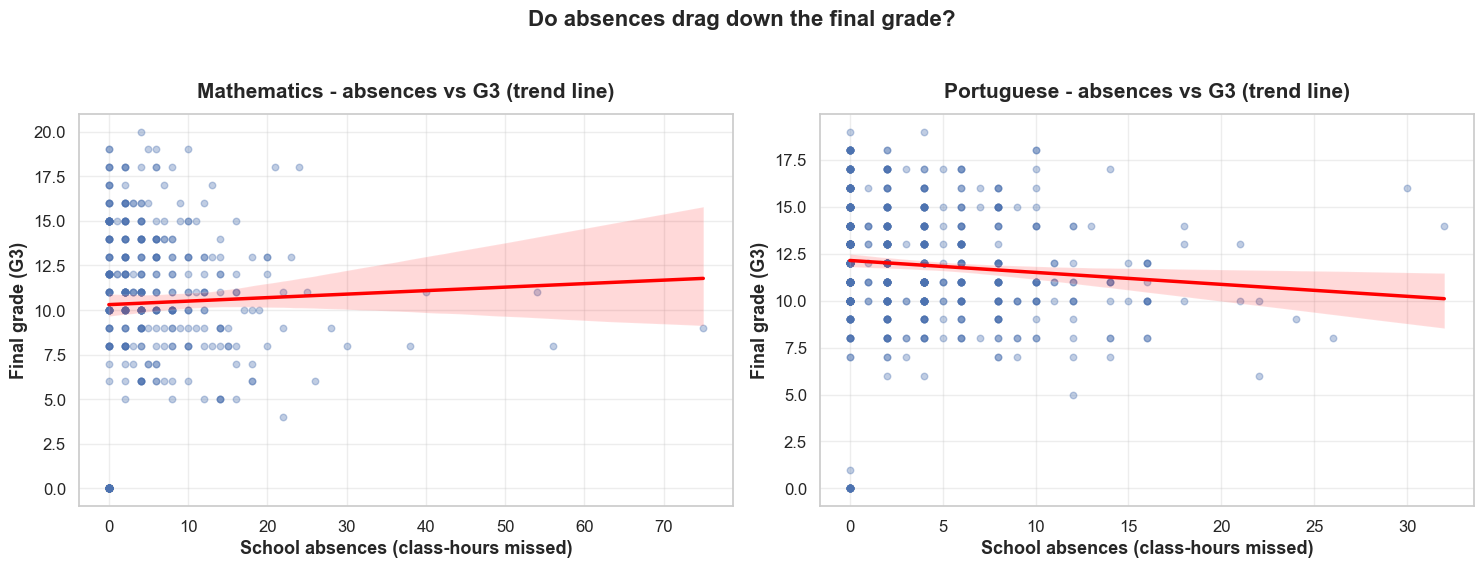

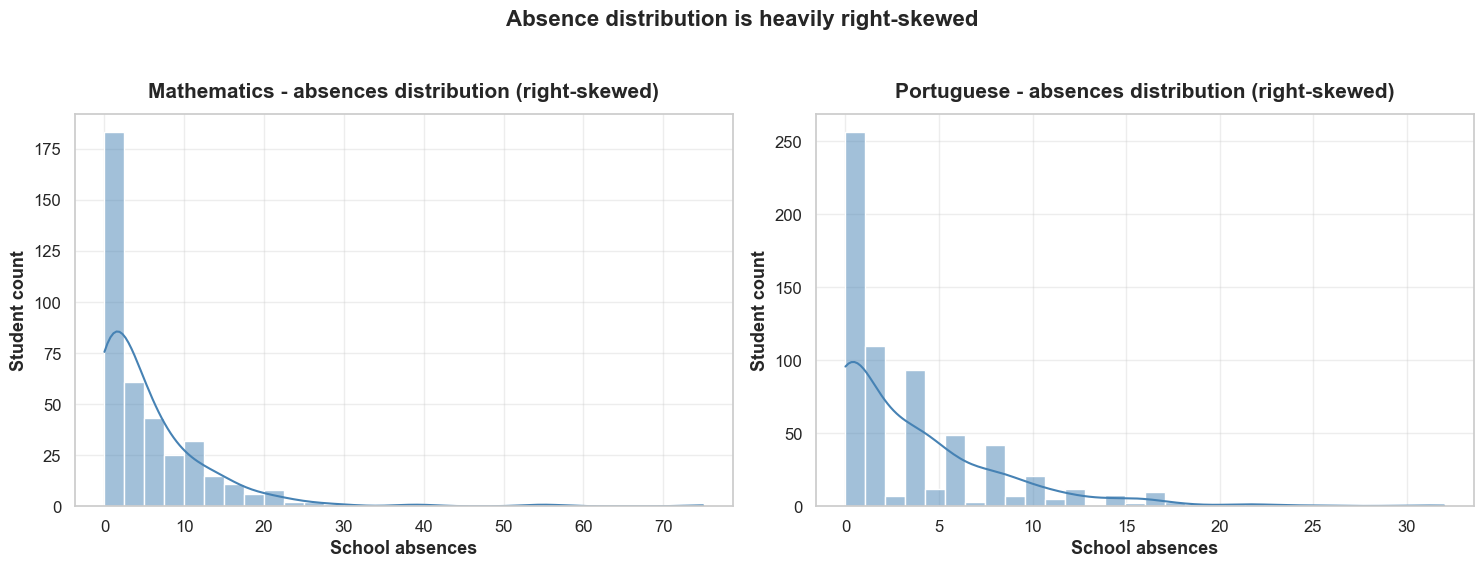

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.regplot(data=df, x='absences', y='G3', ax=ax,
                scatter_kws={'alpha': 0.35, 's': 22},
                line_kws={'color': 'red', 'lw': 2.5})
    style_ax(ax, 'School absences (class-hours missed)', 'Final grade (G3)',
             f'{title} - absences vs G3 (trend line)')
fig.suptitle('Do absences drag down the final grade?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.histplot(df['absences'], bins=30, kde=True, ax=ax,
                 color='steelblue', edgecolor='white')
    style_ax(ax, 'School absences', 'Student count',
             f'{title} - absences distribution (right-skewed)')
fig.suptitle('Absence distribution is heavily right-skewed',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q6. Fairness: do male and female students perform differently, and by how much?

A key **fairness** question. A **violin plot** (with quartiles and mean markers) shows the full `G3` distribution by `sex`, and the mean gap is quantified as a percentage below.

C:\Users\milon\AppData\Local\Temp\ipykernel_1600\3167388618.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=d, x='gender', y='G3', ax=ax, palette='Set1', inner='quart', cut=0)
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\3167388618.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=d, x='gender', y='G3', ax=ax, palette='Set1', inner='quart', cut=0)


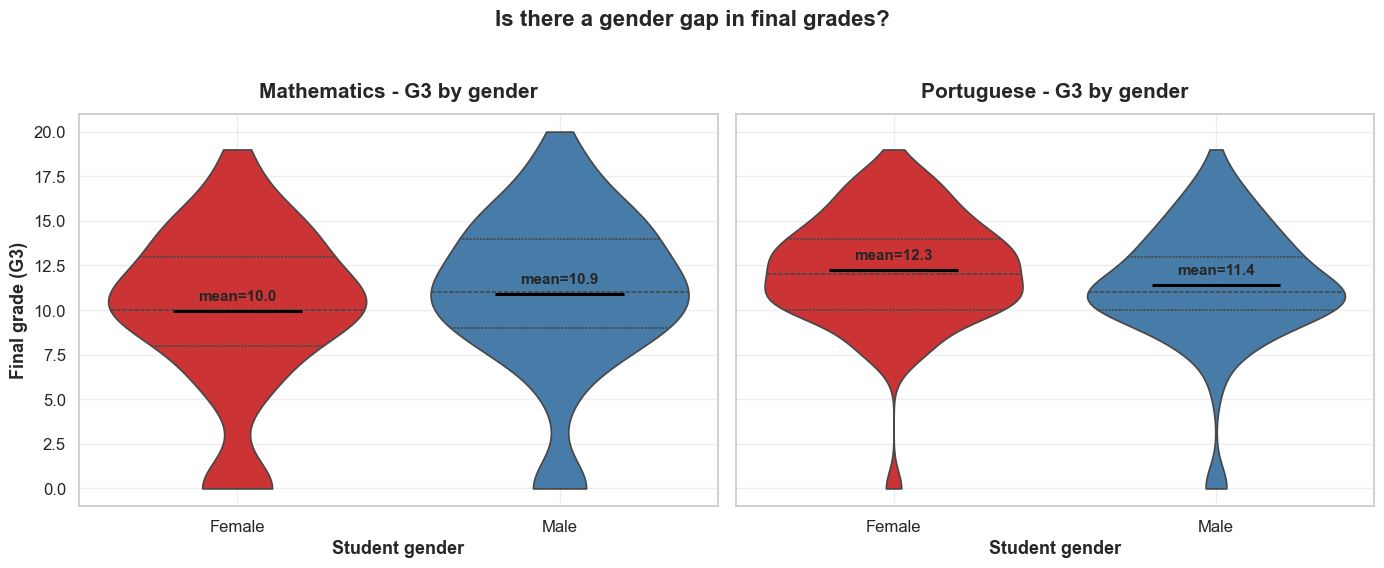

MAT: Male mean = 10.91 | Female mean = 9.97 | gap (M - F) = +0.95 pts (+9.5%)
POR: Male mean = 11.41 | Female mean = 12.25 | gap (M - F) = -0.85 pts (-6.9%)


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    d = df.copy(); d['gender'] = d['sex'].map({'F': 'Female', 'M': 'Male'})
    sns.violinplot(data=d, x='gender', y='G3', ax=ax, palette='Set1', inner='quart', cut=0)
    means = d.groupby('gender')['G3'].mean()
    for x, m in zip(range(len(means)), means.values):
        ax.hlines(m, x - 0.2, x + 0.2, color='black', lw=2.2)
        ax.text(x, m + 0.4, f'mean={m:.1f}', fontsize=11, fontweight='bold',
                va='bottom', ha='center')
    style_ax(ax, 'Student gender', 'Final grade (G3)', f'{title} - G3 by gender')
fig.suptitle('Is there a gender gap in final grades?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()

for name, df in (('MAT', mat_df), ('POR', por_df)):
    mm = df.loc[df.sex == 'M', 'G3'].mean(); ff = df.loc[df.sex == 'F', 'G3'].mean()
    print(f"{name}: Male mean = {mm:.2f} | Female mean = {ff:.2f} | "
          f"gap (M - F) = {mm - ff:+.2f} pts ({(mm / ff - 1) * 100:+.1f}%)")


### Q7. What does the profile of a high achiever vs. a low achiever look like?

A **radar / spider chart** compares high achievers (`G3 >= 15`) against low achievers (`G3 < 10`) on 8 behavioural features expressed as z-scores (relative to each subject's overall mean/std).

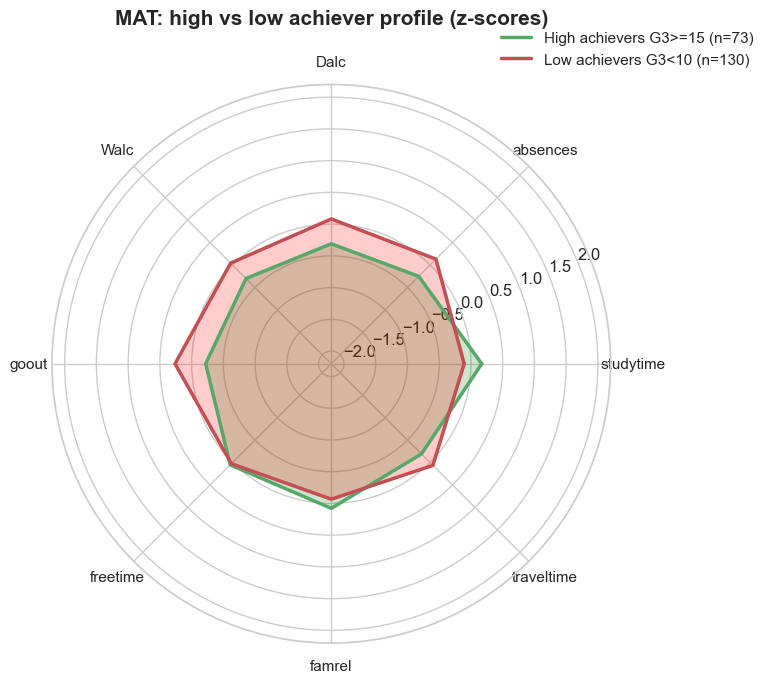

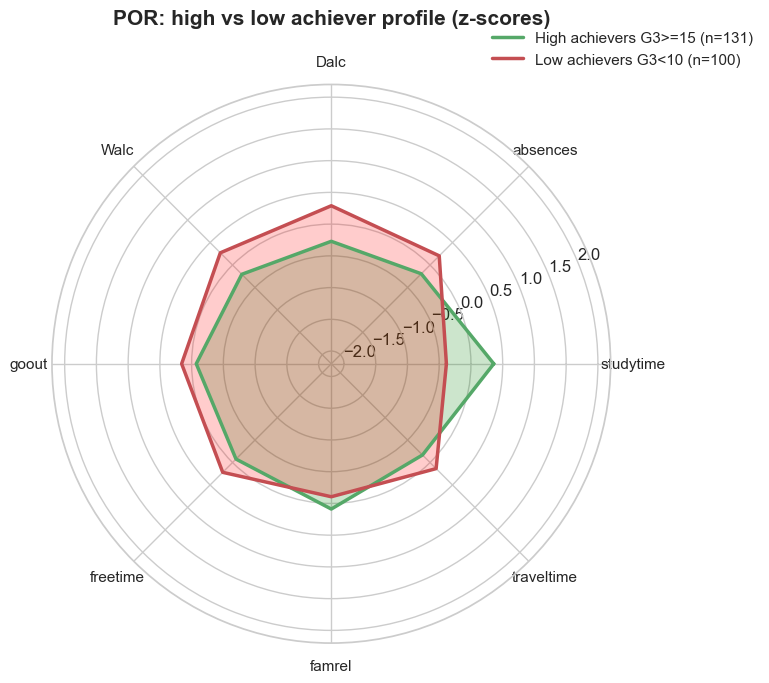

In [25]:
from math import pi

feats = ['studytime', 'absences', 'Dalc', 'Walc', 'goout', 'freetime', 'famrel', 'traveltime']

for df, name in ((mat_df, 'MAT'), (por_df, 'POR')):
    hi = df[df['G3'] >= 15]; lo = df[df['G3'] < 10]
    m, s = df[feats].mean(), df[feats].std()
    props = lambda sub: (sub[feats].mean() - m) / s
    N = len(feats)
    angles = [n / float(N) * 2 * pi for n in range(N)] + [0.0]
    hi_z = list(props(hi).values) + [props(hi).values[0]]
    lo_z = list(props(lo).values) + [props(lo).values[0]]

    fig, ax = plt.subplots(figsize=(7.5, 7.0), subplot_kw={'polar': True})
    ax.plot(angles, hi_z, 'g-', lw=2.5, label=f'High achievers G3>=15 (n={len(hi)})')
    ax.fill(angles, hi_z, color='green', alpha=0.2)
    ax.plot(angles, lo_z, 'r-', lw=2.5, label=f'Low achievers G3<10 (n={len(lo)})')
    ax.fill(angles, lo_z, color='red', alpha=0.2)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(feats, fontsize=11)
    ax.set_ylim(-2.2, 2.2)
    ax.set_title(f'{name}: high vs low achiever profile (z-scores)',
                 fontsize=15, fontweight='bold', pad=22)
    ax.legend(loc='upper right', bbox_to_anchor=(1.28, 1.12), fontsize=11, frameon=False)
    plt.tight_layout(); plt.show()


### Q8. Does a busier social life (going out) cost points on the final grade?

A **lollipop plot** makes the mean final grade per going-out level instantly comparable - each level is a dot on its own stem.

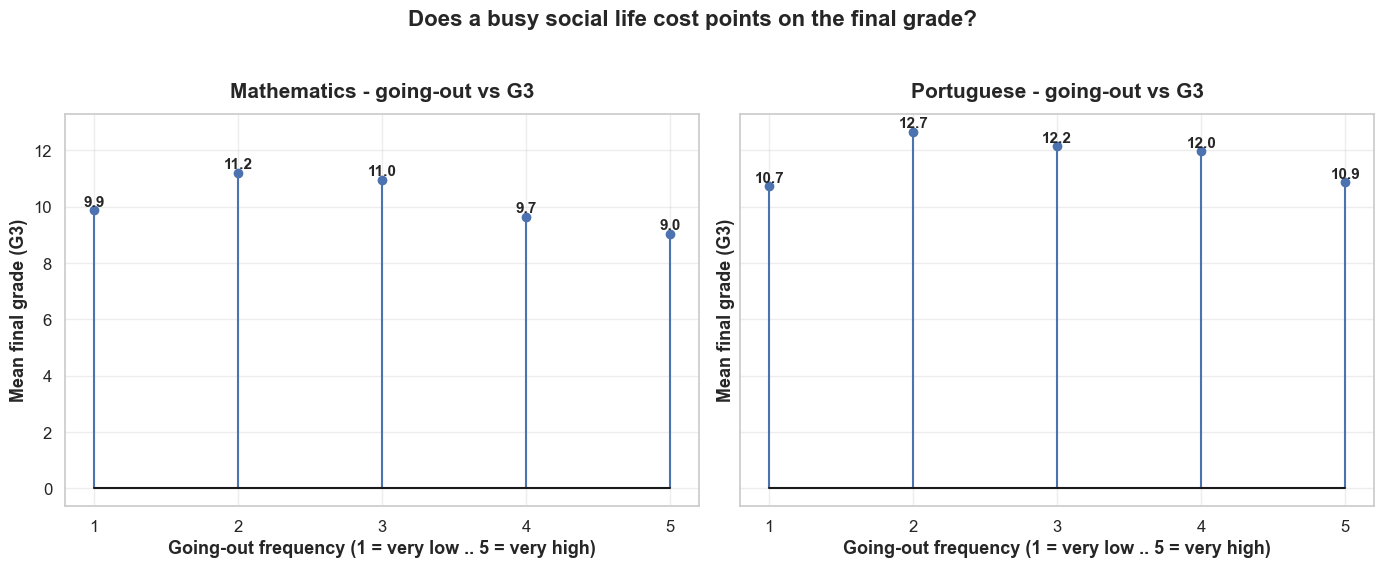

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    m = df.groupby('goout')['G3'].mean()
    ax.stem(m.index, m.values, linefmt='C0-', markerfmt='oC0', basefmt='k-')
    ax.set_xticks(m.index)
    for x, v in zip(m.index, m.values):
        ax.text(x, v + 0.15, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')
    style_ax(ax, 'Going-out frequency (1 = very low .. 5 = very high)',
             'Mean final grade (G3)', f'{title} - going-out vs G3')
fig.suptitle('Does a busy social life cost points on the final grade?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q9. Which school performs better - Gabriel Pereira (GP) or Mousinho da Silveira (MS)?

A **letter-value (boxen) plot** reveals the full grade distribution at each school, and the mean is annotated on each distribution.

C:\Users\milon\AppData\Local\Temp\ipykernel_1600\4145845790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=d, x='_school', y='G3', ax=ax, palette='cubehelix')
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\4145845790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=d, x='_school', y='G3', ax=ax, palette='cubehelix')


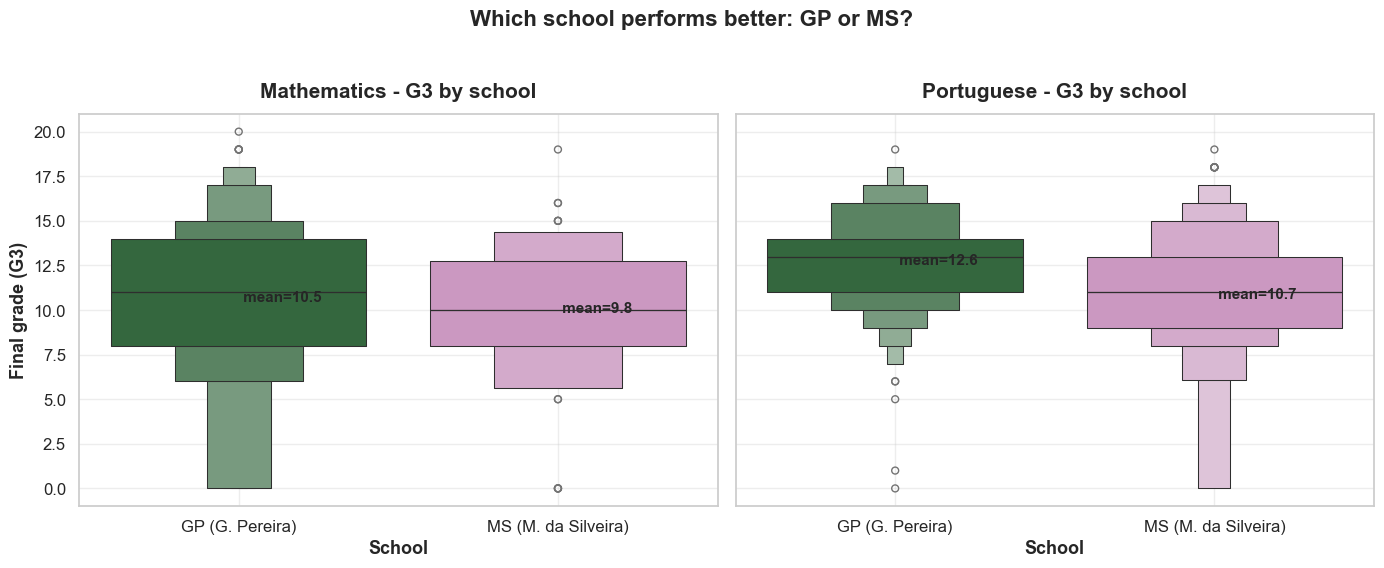

In [27]:
SCHOOL_LBL = {'GP': 'GP (G. Pereira)', 'MS': 'MS (M. da Silveira)'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    d = df.copy(); d['_school'] = d['school'].map(SCHOOL_LBL)
    sns.boxenplot(data=d, x='_school', y='G3', ax=ax, palette='cubehelix')
    means = d.groupby('_school')['G3'].mean()
    for x, m in zip(range(len(means)), means.values):
        ax.text(x, m, f' mean={m:.1f}', fontsize=11, fontweight='bold', ha='left')
    style_ax(ax, 'School', 'Final grade (G3)', f'{title} - G3 by school')
fig.suptitle('Which school performs better: GP or MS?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q10. Which school-supports matter most for the final grade?

A **bar-plot grid** compares mean `G3` for `yes` vs `no` across four binary support features, for both subjects.

C:\Users\milon\AppData\Local\Temp\ipykernel_1600\2687506699.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='G3', ax=axes[j, i], palette='Set3',
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\2687506699.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='G3', ax=axes[j, i], palette='Set3',
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\2687506699.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='G3', ax=axes[j, i], palette='Set3',
C:\Users\milon\AppData\Local\Temp\ipykernel_16

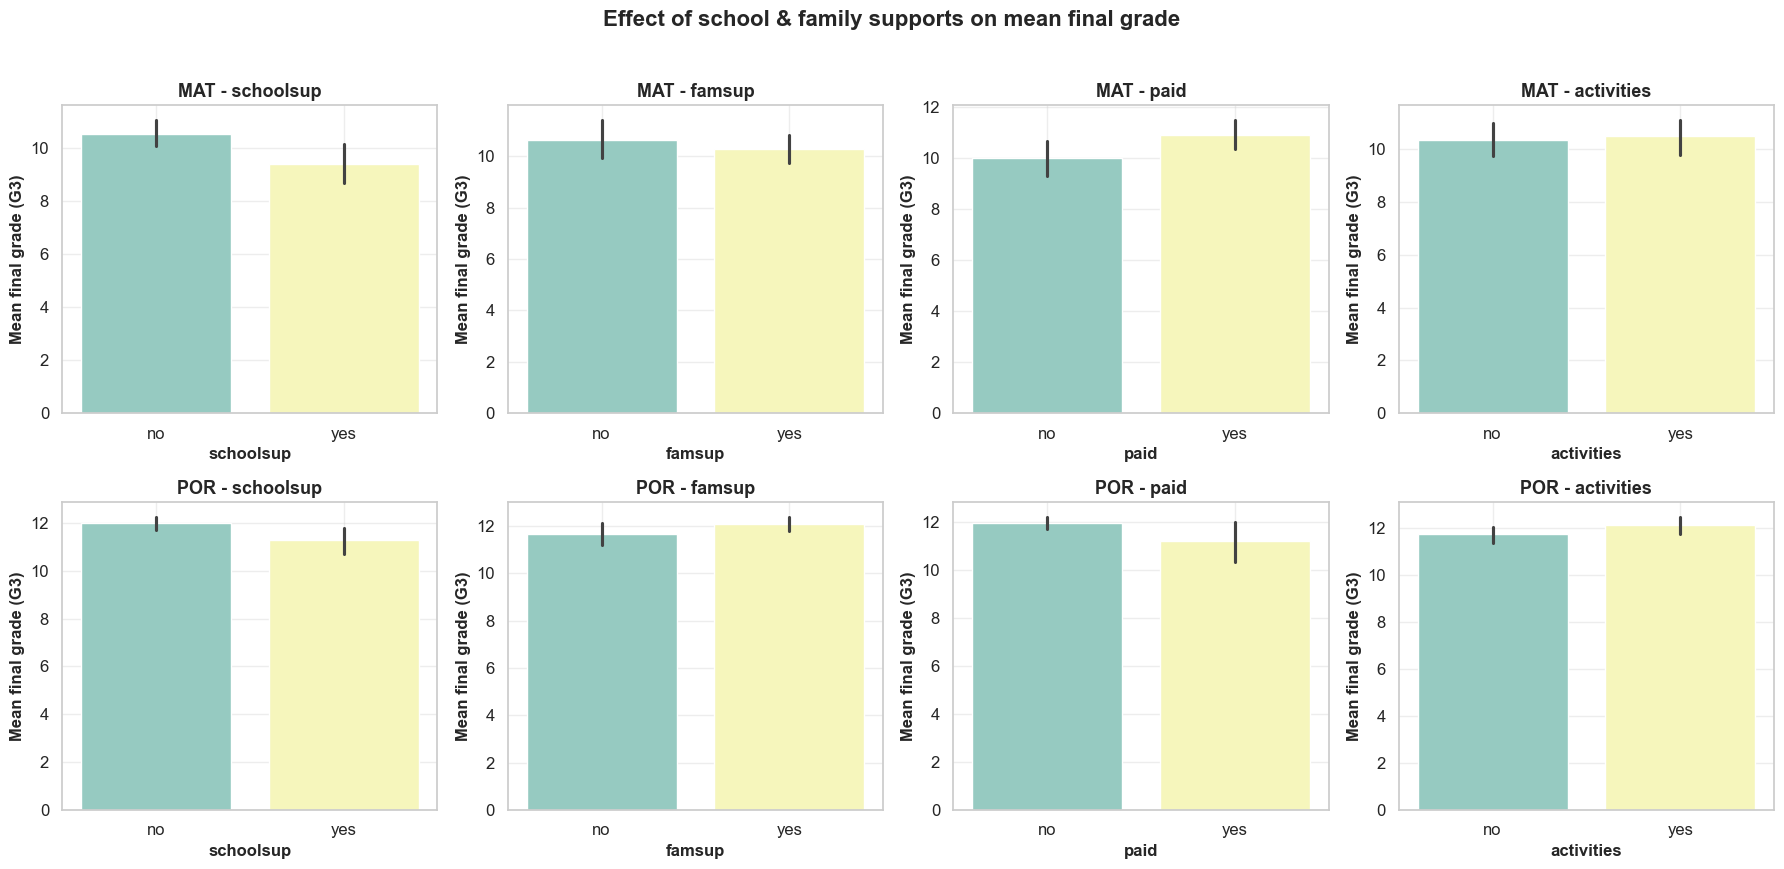

In [28]:
support_cols = ['schoolsup', 'famsup', 'paid', 'activities']
fig, axes = plt.subplots(2, 4, figsize=(18, 8.5))
for j, (df, title) in enumerate(((mat_df, 'MAT'), (por_df, 'POR'))):
    for i, col in enumerate(support_cols):
        sns.barplot(data=df, x=col, y='G3', ax=axes[j, i], palette='Set3',
                    errorbar=('ci', 95), order=['no', 'yes'])
        axes[j, i].set_title(f'{title} - {col}', fontsize=13, fontweight='bold')
        axes[j, i].set_xlabel(col, fontsize=12, fontweight='bold')
        axes[j, i].set_ylabel('Mean final grade (G3)', fontsize=12, fontweight='bold')
        axes[j, i].grid(True, alpha=0.35)
fig.suptitle('Effect of school & family supports on mean final grade',
             fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout(); plt.show()


### Q11. How do the three grading periods (G1, G2, G3) relate, and which features correlate most?

A **correlation heatmap** of the numeric columns shows the strong sequential structure (`G2` -> `G3`) and which factors carry the most linear information about the final grade.

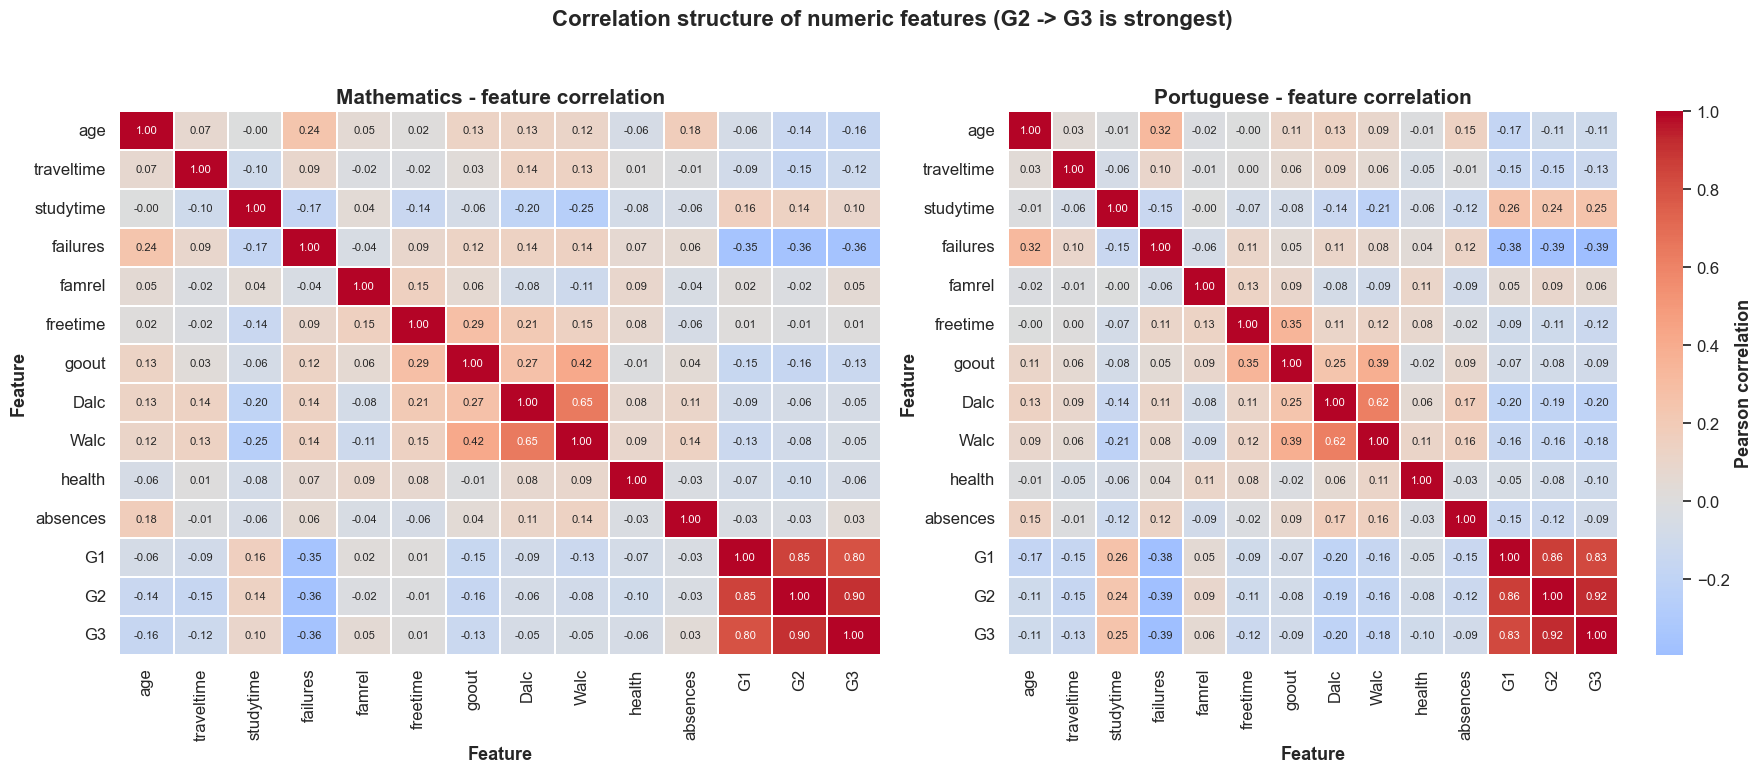

In [29]:
num_cols = ['age', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout',
            'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    corr = df[num_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
                annot_kws={'size': 8}, linewidths=0.3,
                cbar=(ax is axes[1]), cbar_kws={'label': 'Pearson correlation'})
    ax.set_title(f'{title} - feature correlation', fontsize=15, fontweight='bold')
    ax.set_xlabel('Feature', fontsize=13, fontweight='bold')
    ax.set_ylabel('Feature', fontsize=13, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=90)
fig.suptitle('Correlation structure of numeric features (G2 -> G3 is strongest)',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q12. How is the final grade (G3) itself distributed in each subject?

We overlay the **histograms with KDE** of `G3` for both datasets, and flag that many students score exactly 0 (a data-quality quirk worth investigating before modelling).

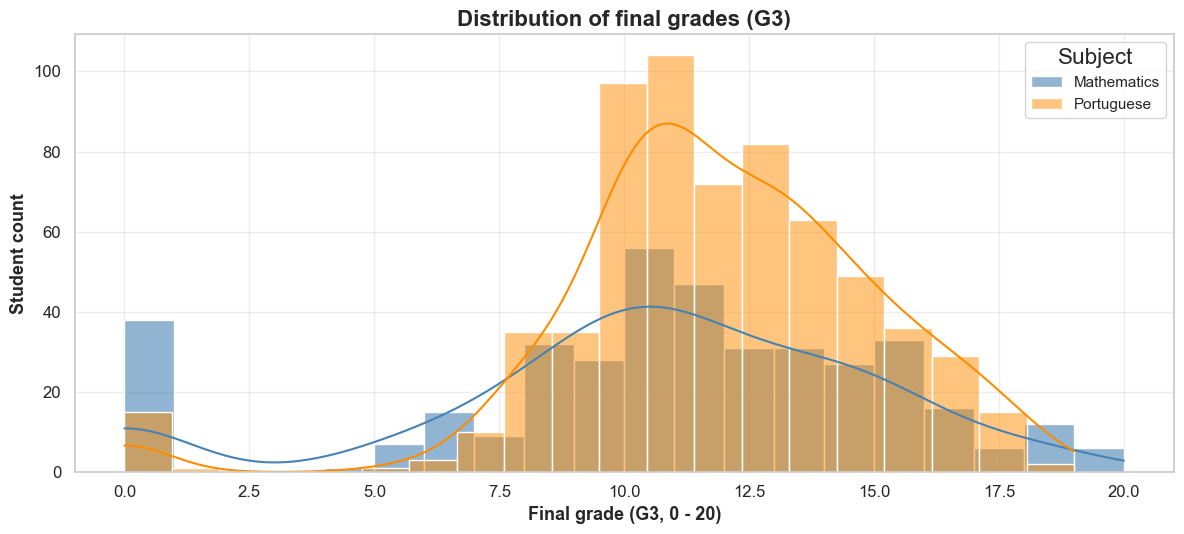

Share of students with G3 = 0 -> MAT: 9.6% | POR: 2.3%


In [30]:
plt.figure(figsize=(12, 5.5))
sns.histplot(mat_df['G3'], bins=20, kde=True, color='steelblue',
             label='Mathematics', alpha=0.6, edgecolor='white')
sns.histplot(por_df['G3'], bins=20, kde=True, color='darkorange',
             label='Portuguese', alpha=0.5, edgecolor='white')
plt.title('Distribution of final grades (G3)', fontsize=16, fontweight='bold')
plt.xlabel('Final grade (G3, 0 - 20)', fontsize=13, fontweight='bold')
plt.ylabel('Student count', fontsize=13, fontweight='bold')
plt.legend(title='Subject'); plt.grid(True, alpha=0.35); plt.tight_layout(); plt.show()

print('Share of students with G3 = 0 -> MAT:',
      f"{(mat_df['G3'] == 0).mean() * 100:.1f}% | POR:",
      f"{(por_df['G3'] == 0).mean() * 100:.1f}%")


### Q13. How does student age affect the final grade - do older students fall behind?

A **strip plot** shows every student's grade at each age (jittered so points don't overlap), with the age-mean marked as a black line.

C:\Users\milon\AppData\Local\Temp\ipykernel_1600\270683694.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='age', y='G3', ax=ax, palette='crest', jitter=0.3,
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\270683694.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='age', y='G3', ax=ax, palette='crest', jitter=0.3,


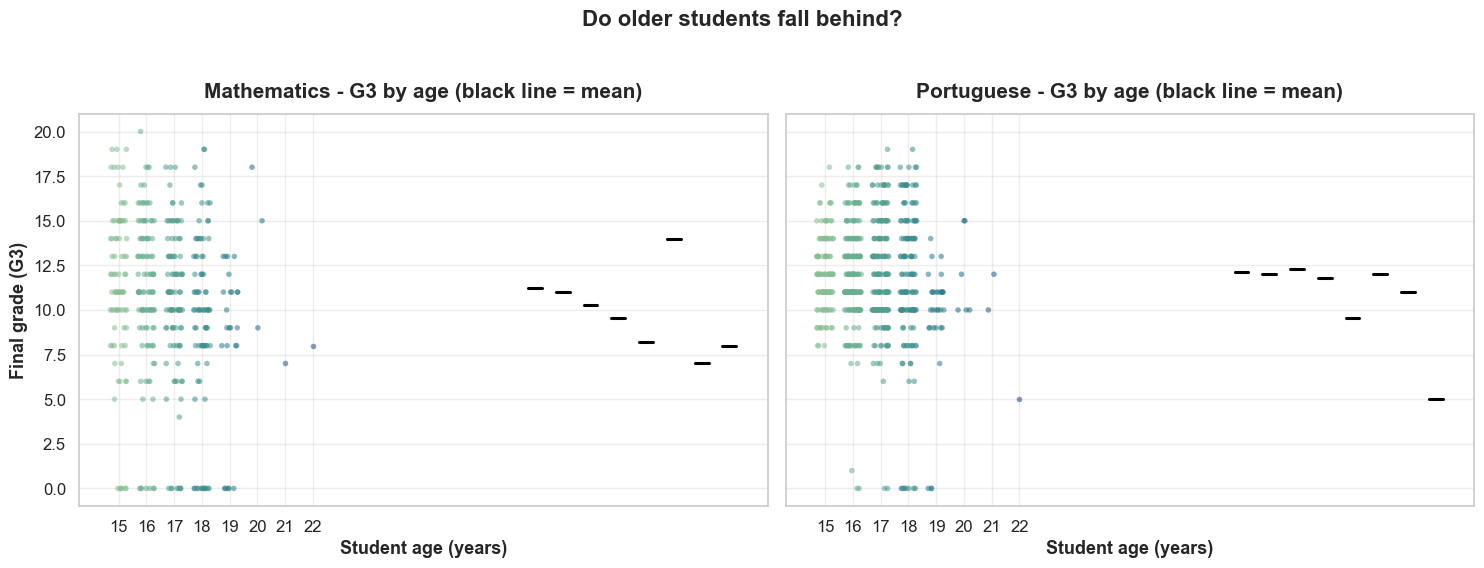

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.stripplot(data=df, x='age', y='G3', ax=ax, palette='crest', jitter=0.3,
                  alpha=0.55, size=4)
    means = df.groupby('age')['G3'].mean()
    for x, m in zip(means.index, means.values):
        ax.plot([x - 0.25, x + 0.25], [m, m], color='black', lw=2.2)
    style_ax(ax, 'Student age (years)', 'Final grade (G3)',
             f'{title} - G3 by age (black line = mean)')
fig.suptitle('Do older students fall behind?', fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q14. Does having home internet access give students an academic edge?

A **lollipop plot** cleanly contrasts the mean grade of students with and without home internet for both subjects.

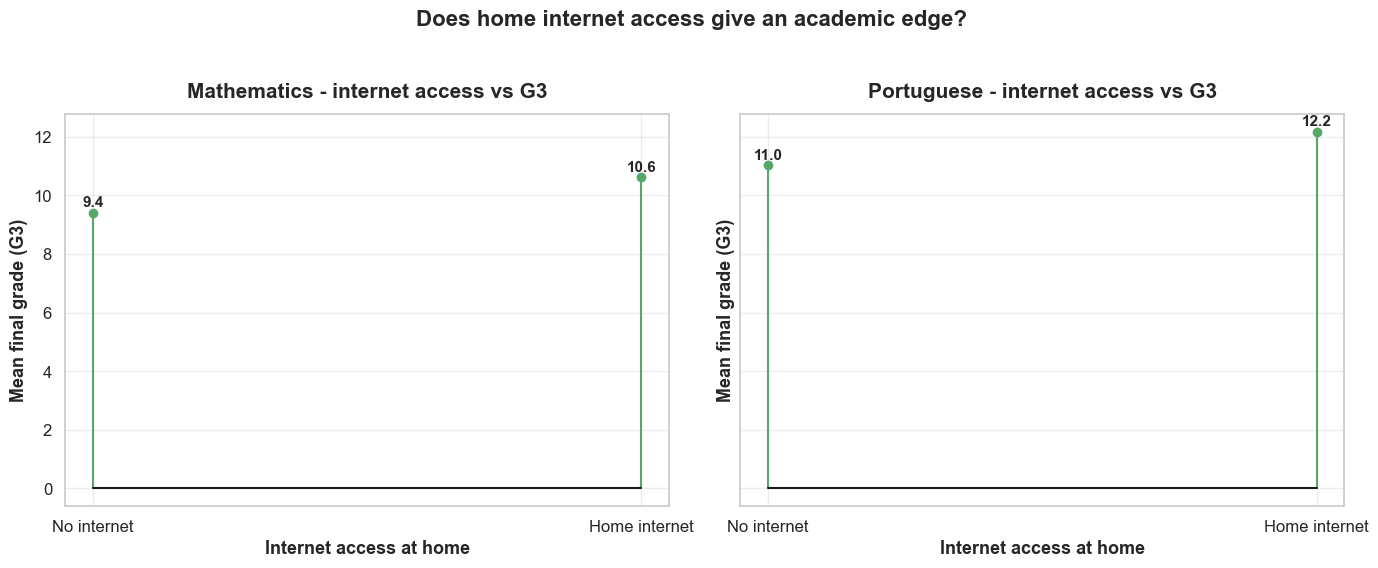

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    m = df.groupby('internet')['G3'].mean()
    order = ['no', 'yes']; vals = [m.get(o, 0.0) for o in order]
    ax.stem(range(len(order)), vals, linefmt='C2-', markerfmt='oC2', basefmt='k-')
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(['No internet', 'Home internet'])
    for i, v in enumerate(vals):
        ax.text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')
    style_ax(ax, 'Internet access at home', 'Mean final grade (G3)',
             f'{title} - internet access vs G3')
fig.suptitle('Does home internet access give an academic edge?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q15. Are students in a romantic relationship performing worse?

A **boxen plot** shows the full grade distribution for students in a relationship vs not, for both subjects.

C:\Users\milon\AppData\Local\Temp\ipykernel_1600\802607242.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=d, x='_r', y='G3', ax=ax, palette='husl', order=['No', 'Yes'])
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\802607242.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=d, x='_r', y='G3', ax=ax, palette='husl', order=['No', 'Yes'])


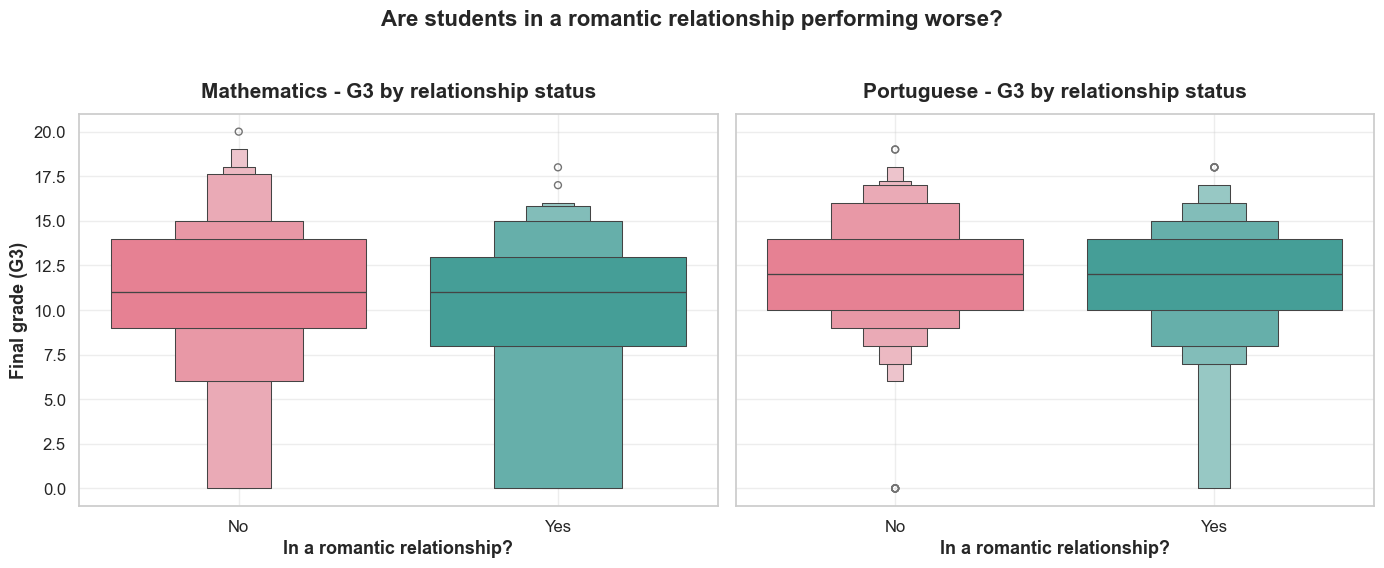

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    d = df.copy(); d['_r'] = d['romantic'].map({'no': 'No', 'yes': 'Yes'})
    sns.boxenplot(data=d, x='_r', y='G3', ax=ax, palette='husl', order=['No', 'Yes'])
    style_ax(ax, 'In a romantic relationship?', 'Final grade (G3)',
             f'{title} - G3 by relationship status')
fig.suptitle('Are students in a romantic relationship performing worse?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q16. Does family structure (family size & parents cohabiting) matter for grades?

A **point-plot grid** (mean + 95 % CI) shows the effect of family size and parental cohabitation status on the mean final grade.

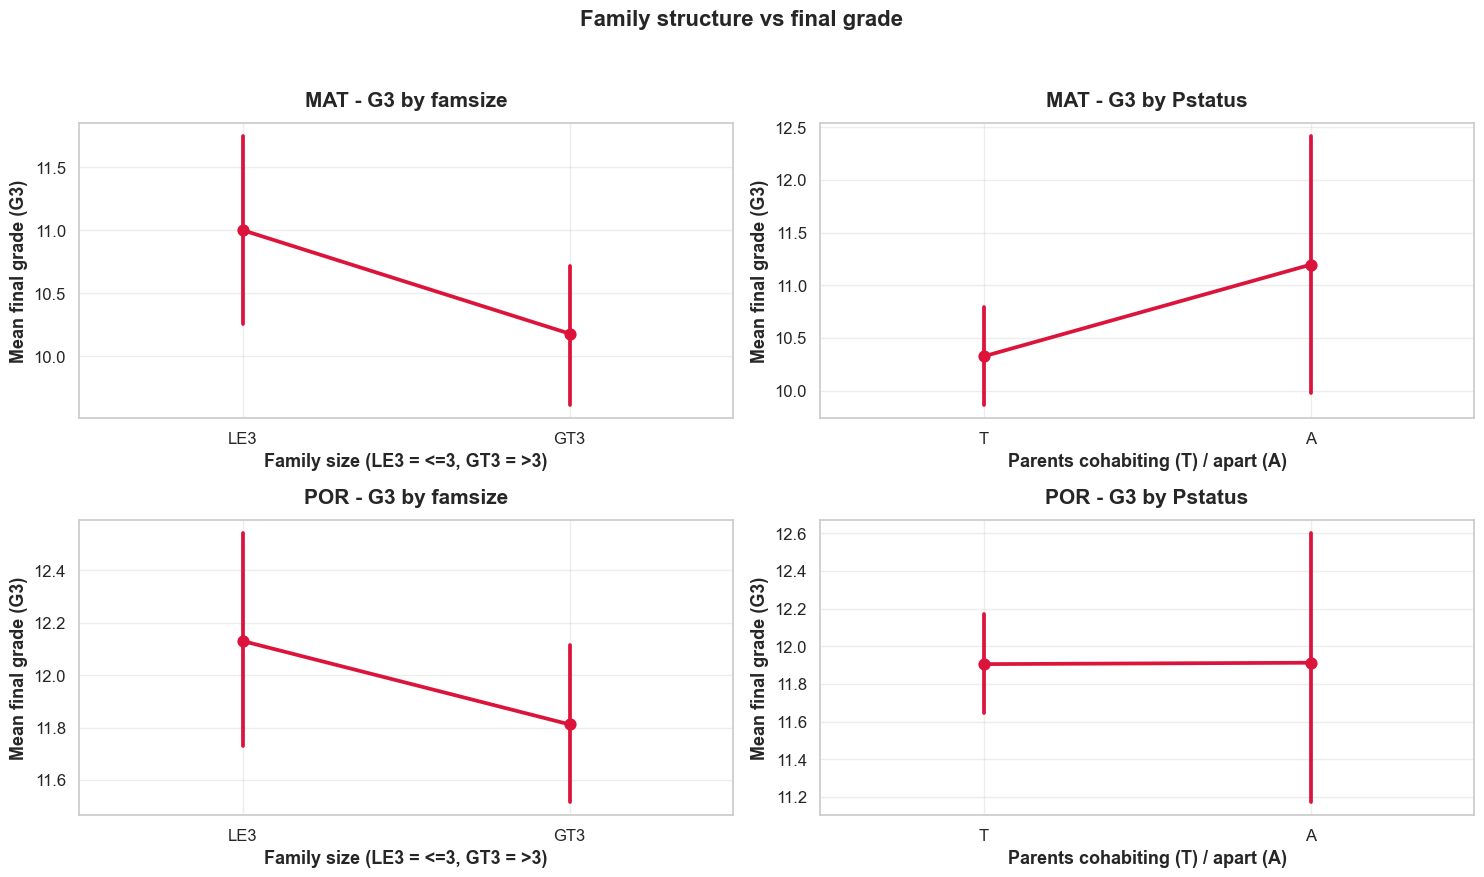

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8.5))
pairs = [('famsize', ['LE3', 'GT3'], 'Family size (LE3 = <=3, GT3 = >3)'),
         ('Pstatus', ['T', 'A'], 'Parents cohabiting (T) / apart (A)')]
for j, (df, title) in enumerate(((mat_df, 'MAT'), (por_df, 'POR'))):
    for i, (col, order, lbl) in enumerate(pairs):
        sns.pointplot(data=df, x=col, y='G3', ax=axes[j, i], order=order,
                      errorbar=('ci', 95), color='crimson')
        style_ax(axes[j, i], lbl, 'Mean final grade (G3)', f'{title} - G3 by {col}')
fig.suptitle('Family structure vs final grade',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q17. Who is a better guardian for performance - mother, father, or someone else?

Comparing the full distribution of final grades by guardian type with a **boxen plot**.

C:\Users\milon\AppData\Local\Temp\ipykernel_1600\4211978570.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=d, x='_g', y='G3', ax=ax, palette='viridis',
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\4211978570.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=d, x='_g', y='G3', ax=ax, palette='viridis',


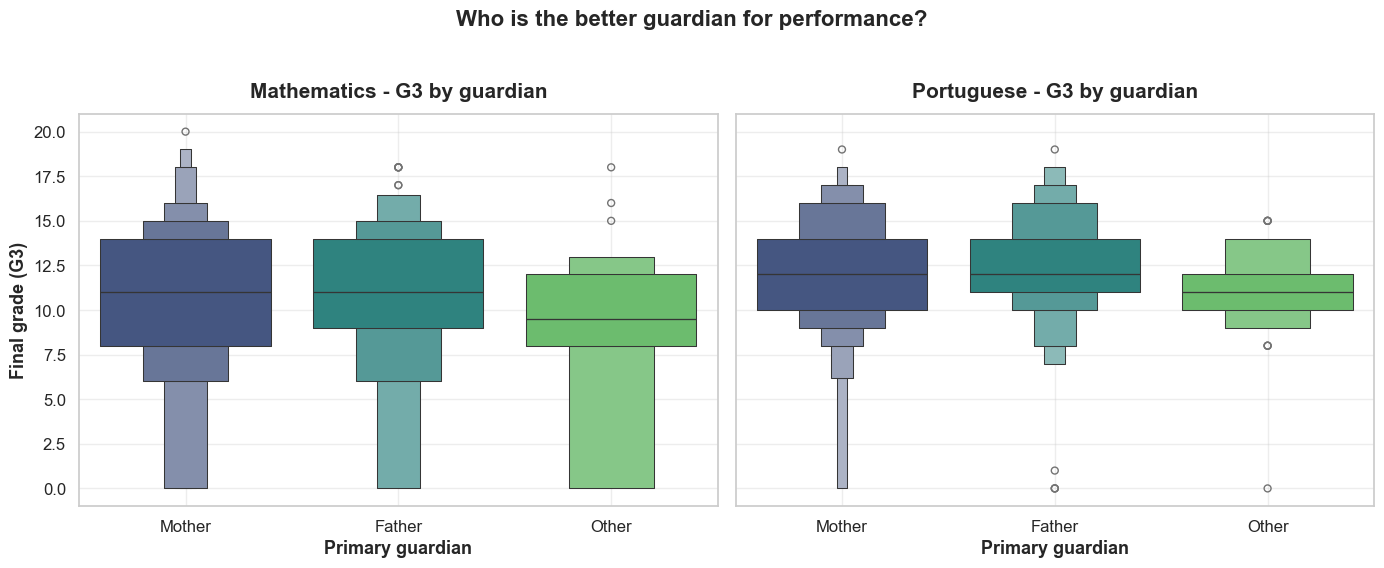

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    d = df.copy()
    d['_g'] = d['guardian'].map({'mother': 'Mother', 'father': 'Father', 'other': 'Other'})
    sns.boxenplot(data=d, x='_g', y='G3', ax=ax, palette='viridis',
                  order=['Mother', 'Father', 'Other'])
    style_ax(ax, 'Primary guardian', 'Final grade (G3)', f'{title} - G3 by guardian')
fig.suptitle('Who is the better guardian for performance?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q18. Which parent's job is associated with the strongest student outcomes?

A **bar-plot grid** of the mean final grade across mother/father occupational categories (with 95 % CI error bars).

C:\Users\milon\AppData\Local\Temp\ipykernel_1600\298771445.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Mjob', y='G3', ax=axes[j, 0],
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\298771445.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Fjob', y='G3', ax=axes[j, 1],
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\298771445.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Mjob', y='G3', ax=axes[j, 0],
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\298771445.py:7: FutureWarning: 

Passin

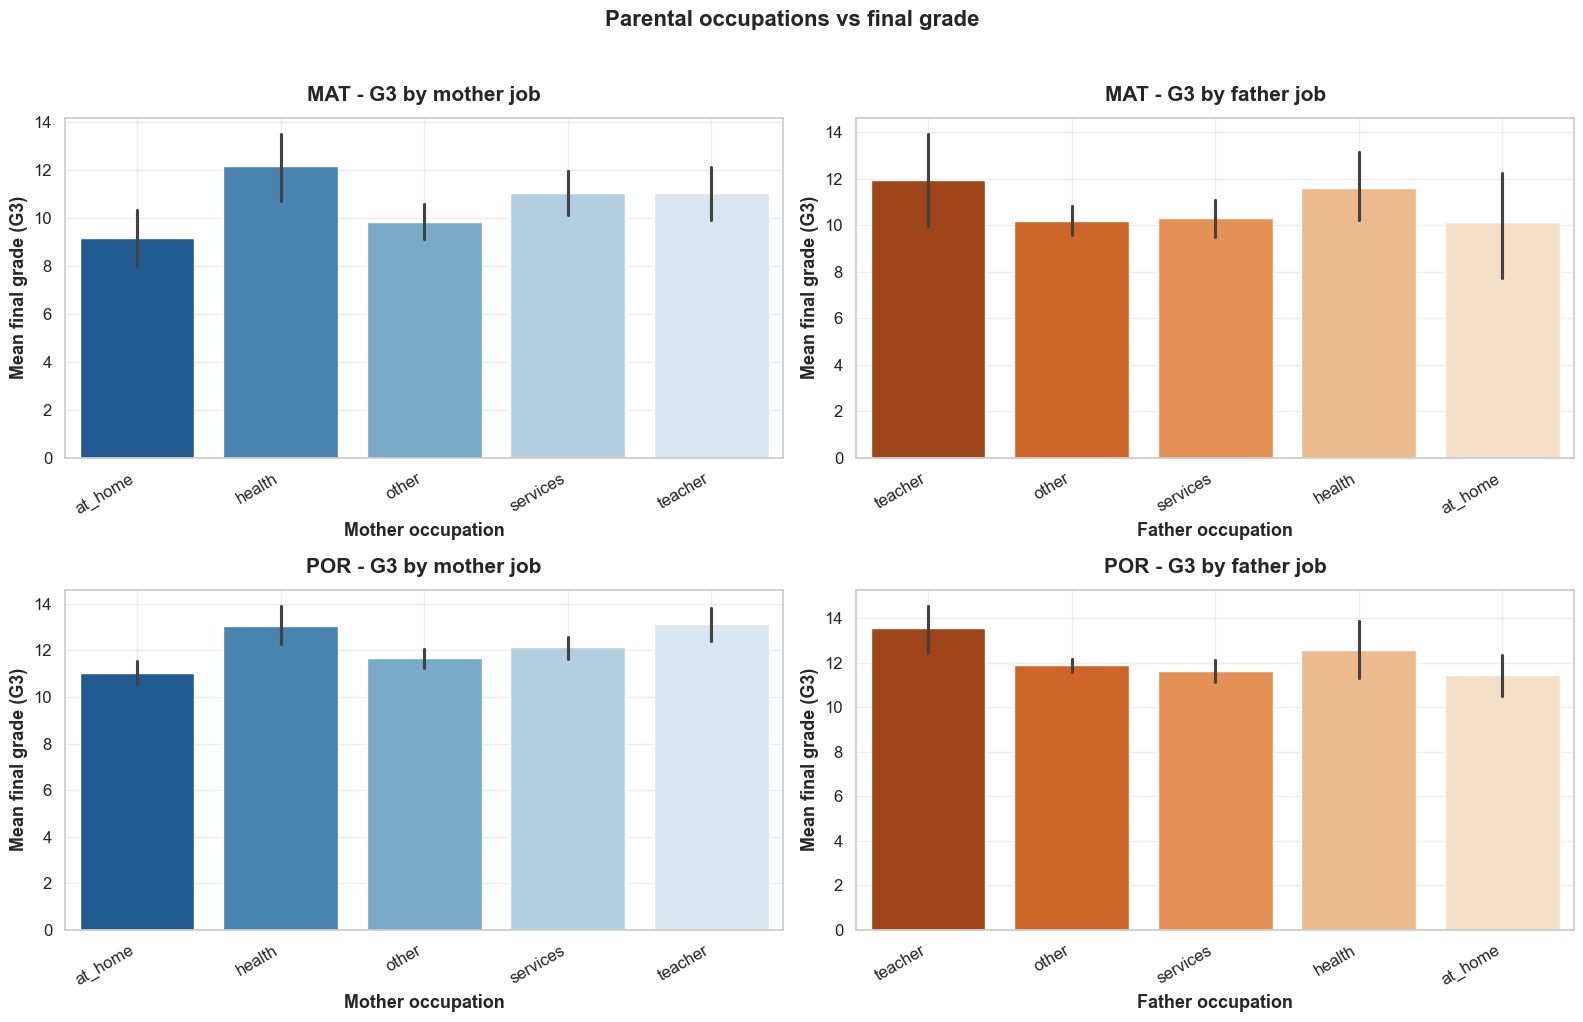

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for j, (df, title) in enumerate(((mat_df, 'MAT'), (por_df, 'POR'))):
    sns.barplot(data=df, x='Mjob', y='G3', ax=axes[j, 0],
                errorbar=('ci', 95), palette='Blues_r')
    style_ax(axes[j, 0], 'Mother occupation', 'Mean final grade (G3)',
             f'{title} - G3 by mother job', rot_xticks=30)
    sns.barplot(data=df, x='Fjob', y='G3', ax=axes[j, 1],
                errorbar=('ci', 95), palette='Oranges_r')
    style_ax(axes[j, 1], 'Father occupation', 'Mean final grade (G3)',
             f'{title} - G3 by father job', rot_xticks=30)
fig.suptitle('Parental occupations vs final grade',
             fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout(); plt.show()


### Q19. Do students with better self-reported health score higher?

A **violin plot** shows the grade distribution at every health level, with the mean + 95 % CI overlaid as a point plot.

C:\Users\milon\AppData\Local\Temp\ipykernel_1600\569742252.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='health', y='G3', ax=ax, palette='YlGnBu', inner='stick')
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\569742252.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='health', y='G3', ax=ax, palette='YlGnBu', inner='stick')


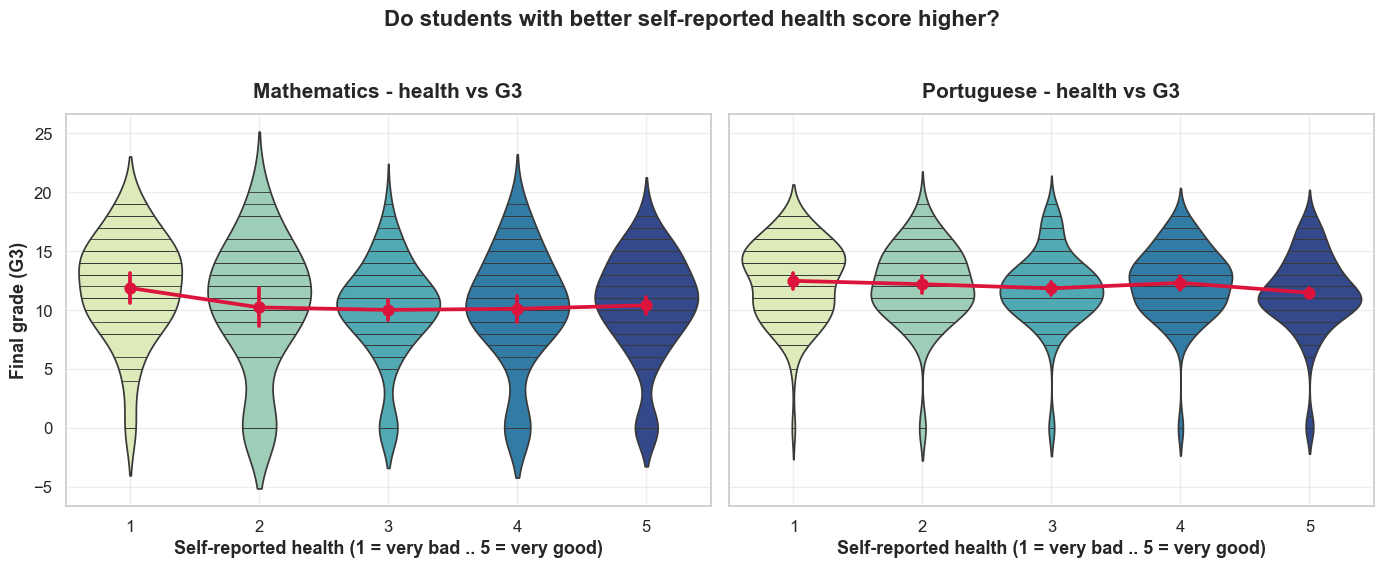

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.violinplot(data=df, x='health', y='G3', ax=ax, palette='YlGnBu', inner='stick')
    sns.pointplot(data=df, x='health', y='G3', ax=ax, color='crimson',
                  errorbar=('ci', 95))
    style_ax(ax, 'Self-reported health (1 = very bad .. 5 = very good)',
             'Final grade (G3)', f'{title} - health vs G3')
fig.suptitle('Do students with better self-reported health score higher?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q20. Does more free time translate into better (or worse) grades?

Free time is ordinal (1..5), so a **box plot** shows the full spread of grades at each level.

C:\Users\milon\AppData\Local\Temp\ipykernel_1600\4151101747.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='freetime', y='G3', ax=ax, palette='PuBuGn', width=0.55)
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\4151101747.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='freetime', y='G3', ax=ax, palette='PuBuGn', width=0.55)


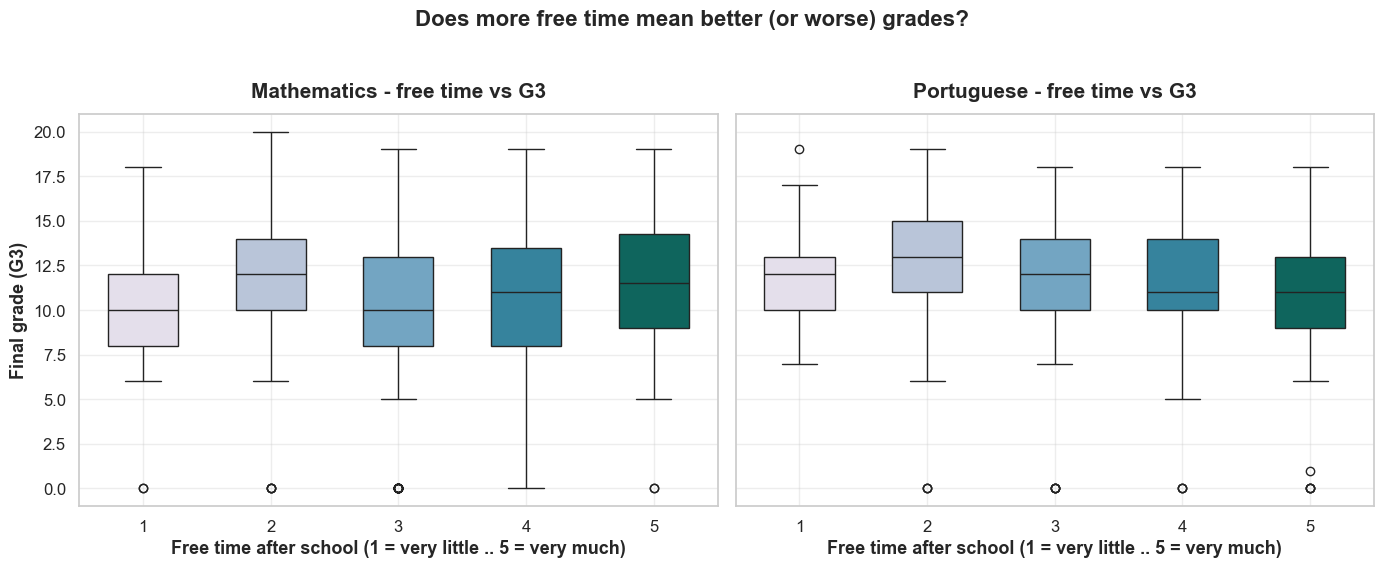

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.boxplot(data=df, x='freetime', y='G3', ax=ax, palette='PuBuGn', width=0.55)
    style_ax(ax, 'Free time after school (1 = very little .. 5 = very much)',
             'Final grade (G3)', f'{title} - free time vs G3')
fig.suptitle('Does more free time mean better (or worse) grades?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q21. Is a longer commute to school associated with lower grades?

Travel time is ordinal (1..4), so a **line plot with a 95 % CI ribbon** reveals the trend.

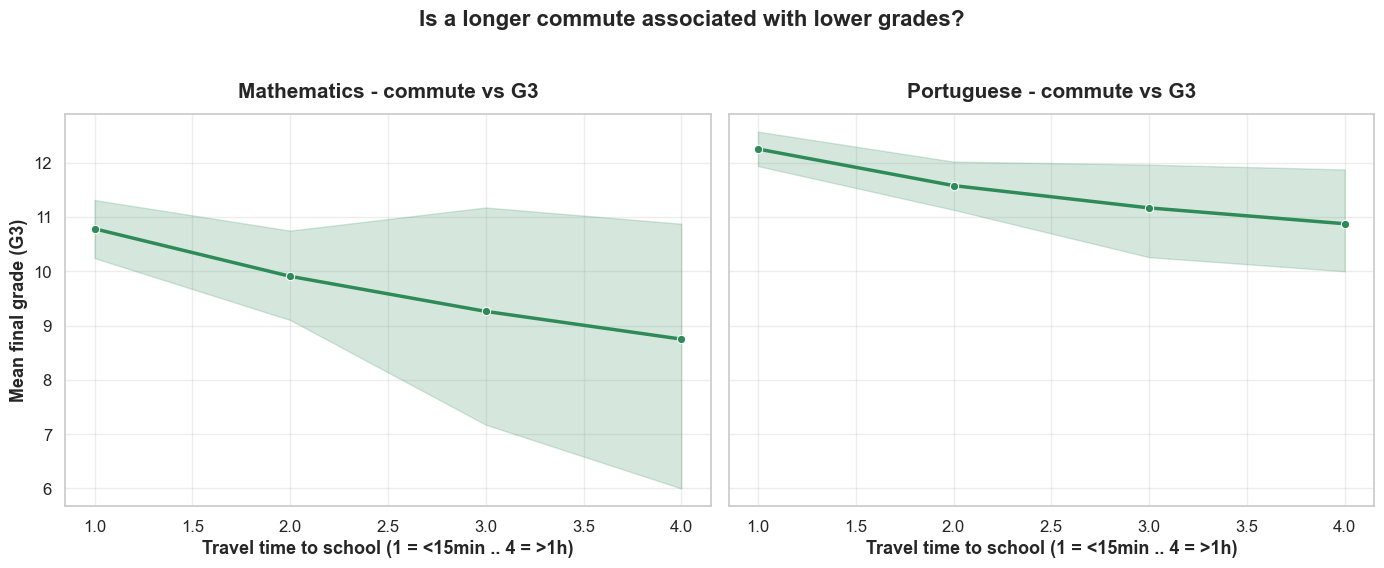

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.lineplot(data=df, x='traveltime', y='G3', ax=ax, marker='o', lw=2.5,
                 errorbar=('ci', 95), color='seagreen')
    style_ax(ax, 'Travel time to school (1 = <15min .. 4 = >1h)',
             'Mean final grade (G3)', f'{title} - commute vs G3')
fig.suptitle('Is a longer commute associated with lower grades?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q22. Do weekday (Dalc) and weekend (Walc) alcohol habits go together?

A **cross-tabulation heatmap** counts students at each (weekday, weekend) drinking combination - the strong diagonal shows the two habits move together.

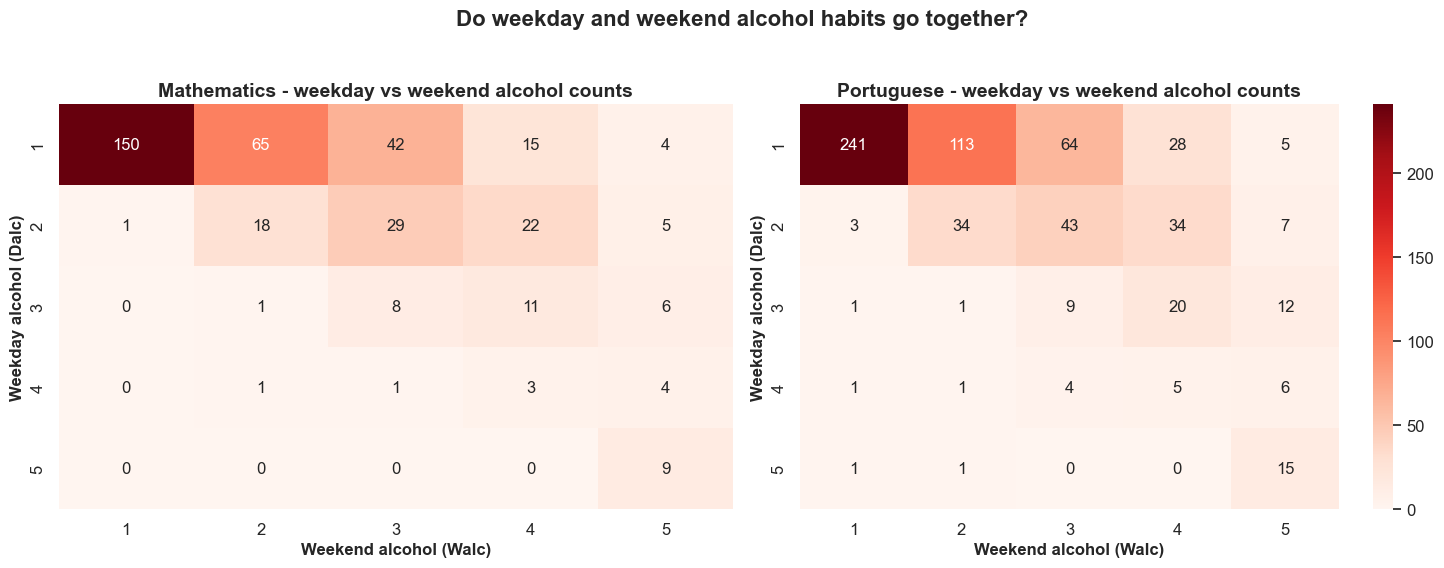

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    ct = pd.crosstab(df['Dalc'], df['Walc'])
    sns.heatmap(ct, annot=True, fmt='d', cmap='Reds', ax=ax, cbar=(ax is axes[1]))
    ax.set_title(f'{title} - weekday vs weekend alcohol counts',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Weekend alcohol (Walc)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Weekday alcohol (Dalc)', fontsize=12, fontweight='bold')
fig.suptitle('Do weekday and weekend alcohol habits go together?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q23. How does the G1 -> G2 -> G3 grade progression look, and how often do students decline?

A **pairplot (scatter matrix with regression + KDE diagonal)** for the three grading periods, plus a **histogram** of the `G3 - G2` change (negative = decline).

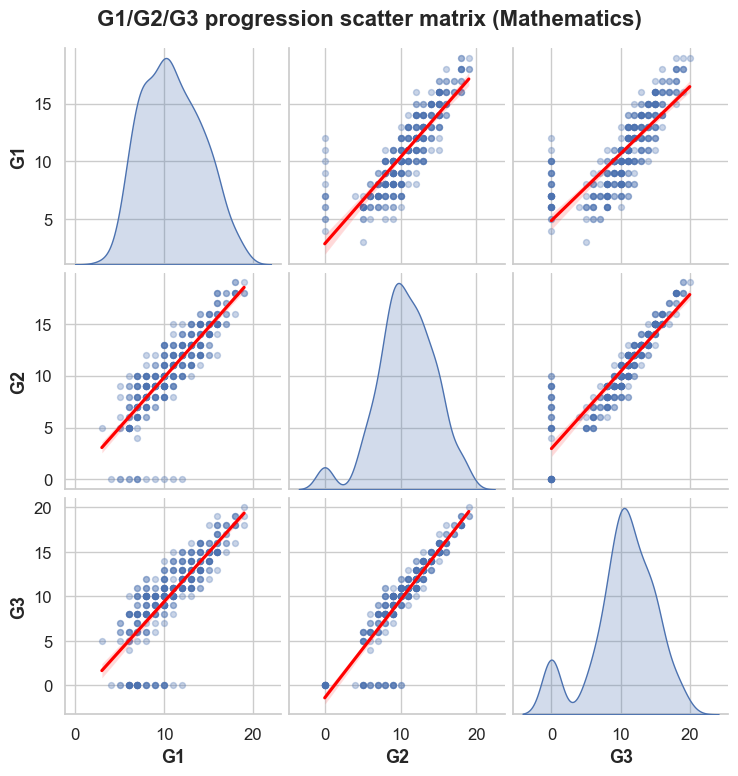

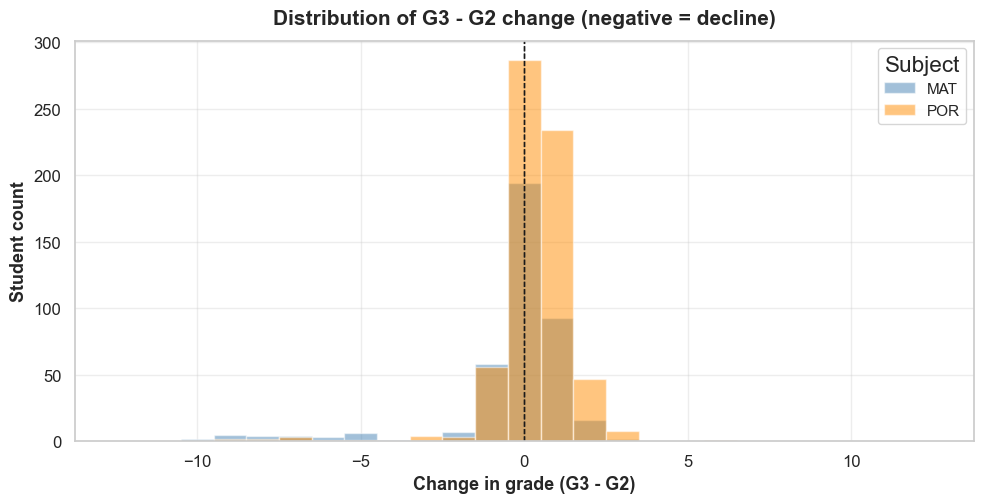

In [41]:
g = sns.pairplot(mat_df[['G1', 'G2', 'G3']], kind='reg', diag_kind='kde',
                 plot_kws={'scatter_kws': {'alpha': 0.3, 's': 18},
                           'line_kws': {'color': 'red'}})
g.fig.suptitle('G1/G2/G3 progression scatter matrix (Mathematics)',
               fontsize=16, fontweight='bold', y=1.03)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5.2))
for df, name, color in ((mat_df, 'MAT', 'steelblue'), (por_df, 'POR', 'darkorange')):
    delta = df['G3'] - df['G2']
    ax.hist(delta, bins=np.arange(-12.5, 13.5, 1), alpha=0.5, label=name,
            color=color, edgecolor='white')
    ax.axvline(0, color='k', lw=1, ls='--')
style_ax(ax, 'Change in grade (G3 - G2)', 'Student count',
         'Distribution of G3 - G2 change (negative = decline)')
ax.legend(title='Subject'); fig.tight_layout(); plt.show()


### Q24. Interaction: does the effect of study time depend on how often students go out?

A **grouped point plot** (study time on the x-axis, going-out frequency as hue, mean grade with 95 % CI) shows the interaction: parallel lines mean no interaction, crossing lines do.

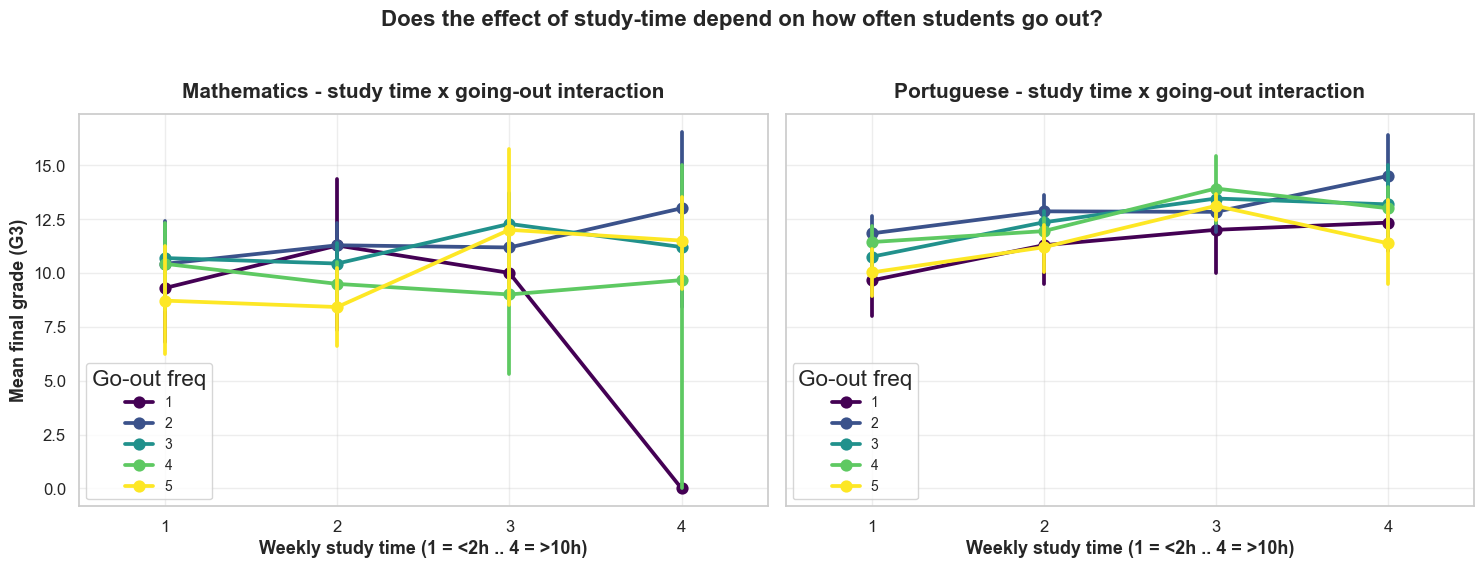

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.pointplot(data=df, x='studytime', y='G3', hue='goout', ax=ax,
                  errorbar=('ci', 95), palette='viridis')
    style_ax(ax, 'Weekly study time (1 = <2h .. 4 = >10h)',
             'Mean final grade (G3)',
             f'{title} - study time x going-out interaction')
    ax.legend(title='Go-out freq', fontsize=10)
fig.suptitle('Does the effect of study-time depend on how often students go out?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q25. Interaction: does family relationship quality buffer the harm of alcohol on grades?

A **heatmap** of mean final grade across {family relationship x weekend alcohol} - a green patch at high alcohol + high family quality would show a buffering effect.

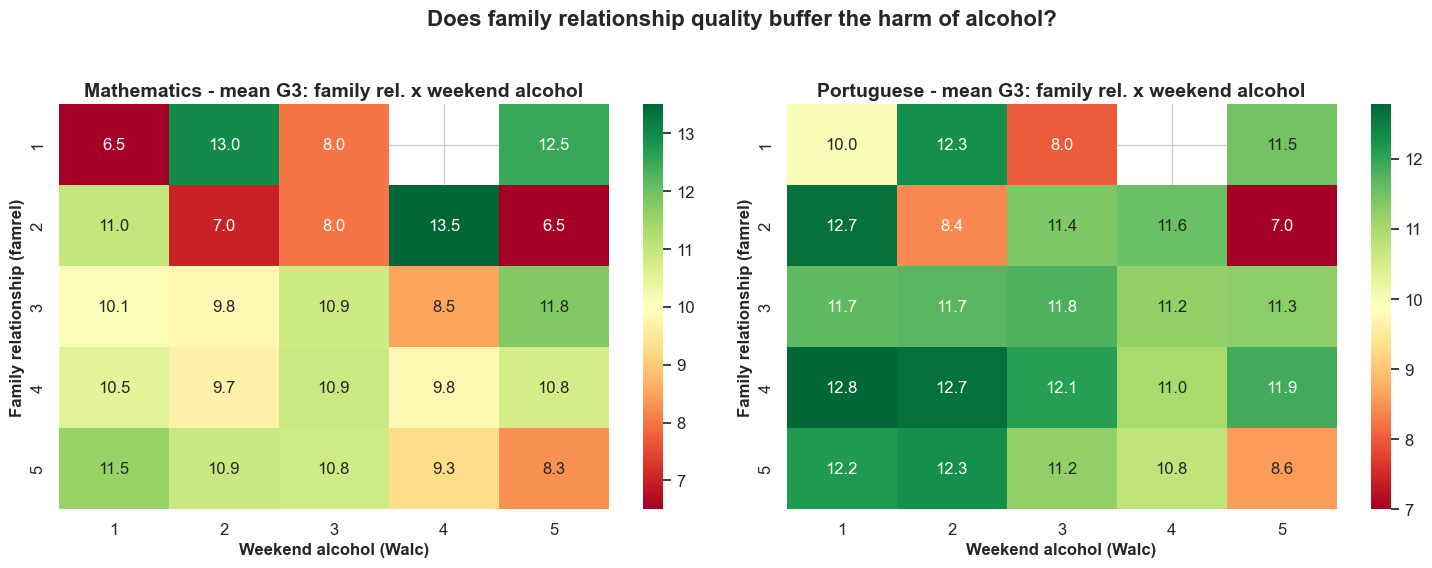

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    piv = df.pivot_table(index='famrel', columns='Walc', values='G3', aggfunc='mean')
    sns.heatmap(piv, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax)
    ax.set_title(f'{title} - mean G3: family rel. x weekend alcohol',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Weekend alcohol (Walc)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Family relationship (famrel)', fontsize=12, fontweight='bold')
fig.suptitle('Does family relationship quality buffer the harm of alcohol?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q26. Who improves the most between G1 and G3 - and does school support explain it?

A **point plot** (mean + 95 % CI) of the `G3 - G1` change split by whether school support was received; the zero line marks no net change.

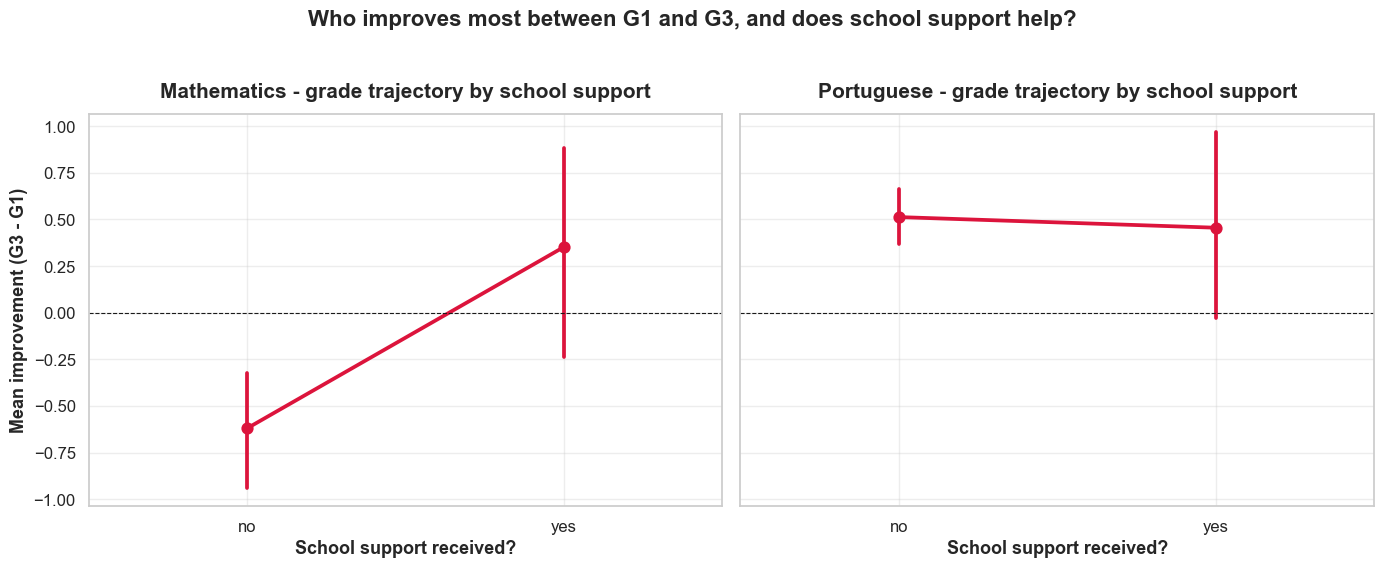

In [45]:
mat_df2 = mat_df.copy(); mat_df2['improve'] = mat_df2['G3'] - mat_df2['G1']
por_df2 = por_df.copy(); por_df2['improve'] = por_df2['G3'] - por_df2['G1']
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, df, title in zip(axes, (mat_df2, por_df2), ('Mathematics', 'Portuguese')):
    sns.pointplot(data=df, x='schoolsup', y='improve', ax=ax, order=['no', 'yes'],
                  errorbar=('ci', 95), color='crimson')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    style_ax(ax, 'School support received?', 'Mean improvement (G3 - G1)',
             f'{title} - grade trajectory by school support')
fig.suptitle('Who improves most between G1 and G3, and does school support help?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q27. Rainbow plot: how do final grades distribute across ages, split by subject?

A **rainbow scatter plot** colours each age group with a different colour; the black ticks mark the mean grade of each age.

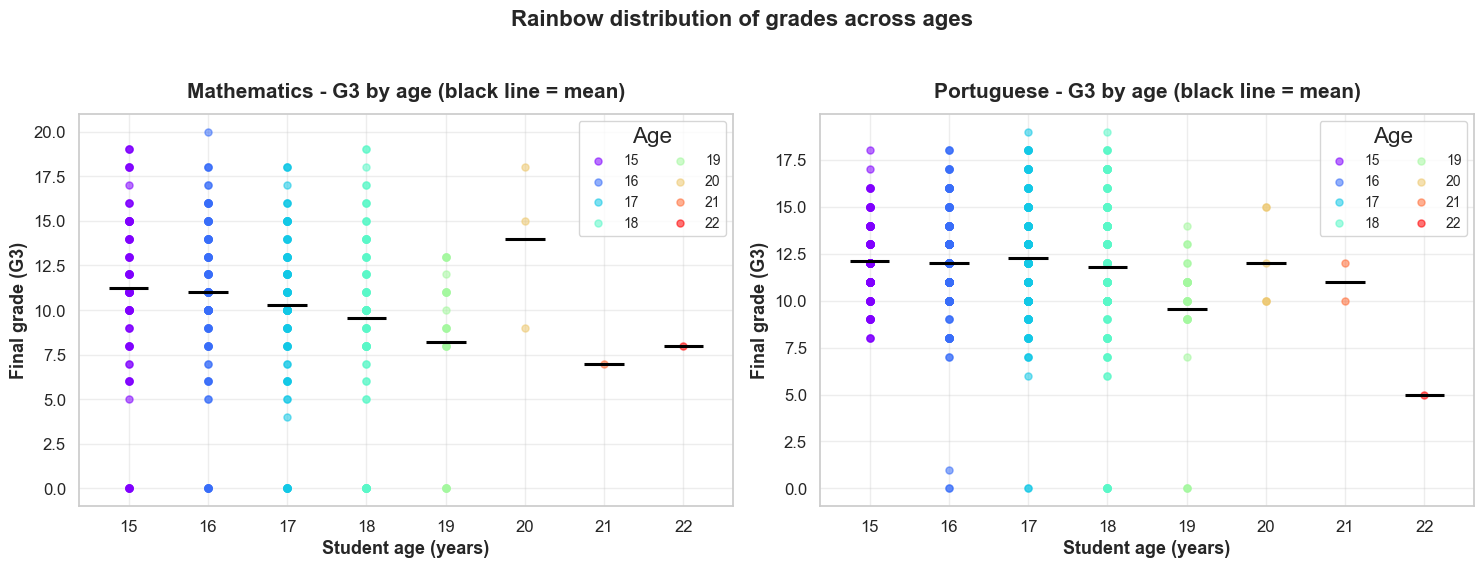

In [46]:
from matplotlib.cm import rainbow
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    ages = sorted(df['age'].unique())
    colors = rainbow(np.linspace(0, 1, len(ages)))
    for a, c in zip(ages, colors):
        sub = df[df['age'] == a]['G3']
        ax.scatter([a] * len(sub), sub, color=c, alpha=0.55, s=26, label=str(a))
        ax.hlines(sub.mean(), a - 0.25, a + 0.25, color='black', lw=2.2)
    style_ax(ax, 'Student age (years)', 'Final grade (G3)',
             f'{title} - G3 by age (black line = mean)')
    ax.legend(title='Age', ncol=2, fontsize=10)
fig.suptitle('Rainbow distribution of grades across ages',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q28. Rainbow stacked view: does the mix of pass/fail change with weekend alcohol level?

A **100 % stacked bar plot** shows how the share of failed / passed students changes as weekend alcohol (Walc) rises.

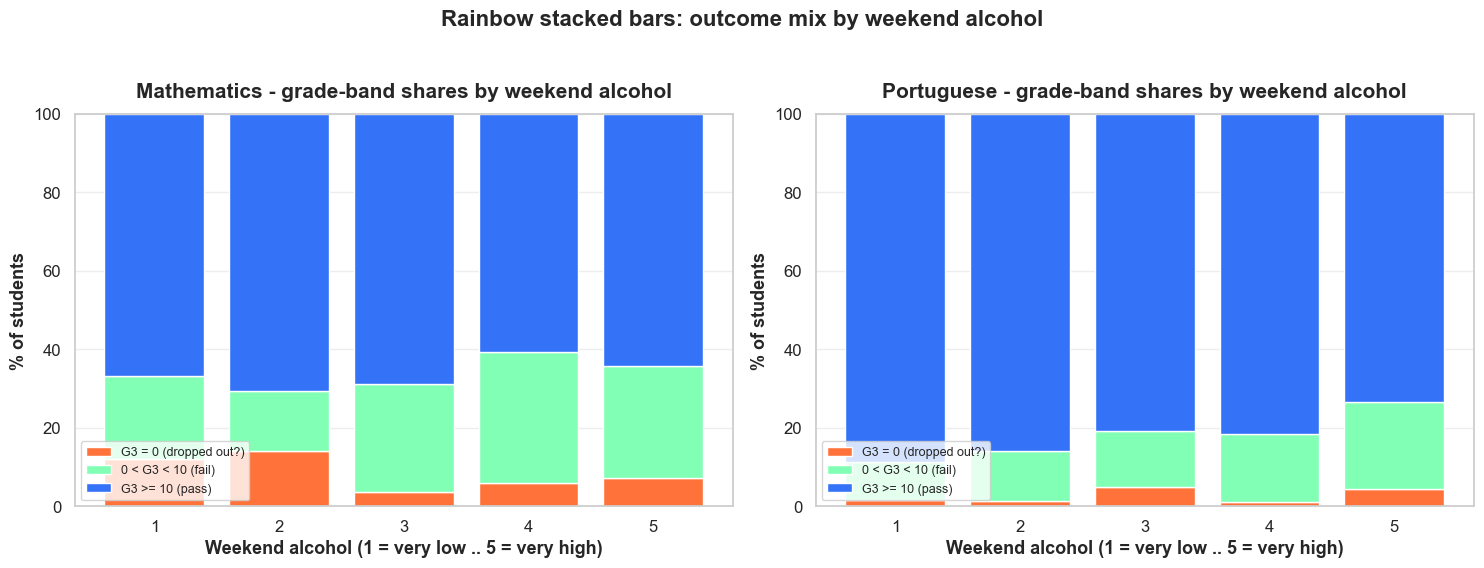

In [47]:
from matplotlib.cm import rainbow
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    levels = sorted(df['Walc'].unique())
    props = []
    for w in levels:
        sub = df[df['Walc'] == w]['G3']
        props.append([(sub == 0).mean(), ((sub > 0) & (sub < 10)).mean(), (sub >= 10).mean()])
    props = np.array(props) * 100
    colors = rainbow(np.linspace(0.85, 0.15, 3))
    bottom = np.zeros(len(levels))
    for i, lab in enumerate(['G3 = 0 (dropped out?)', '0 < G3 < 10 (fail)', 'G3 >= 10 (pass)']):
        ax.bar(levels, props[:, i], bottom=bottom, color=colors[i], label=lab, edgecolor='white')
        bottom += props[:, i]
    style_ax(ax, 'Weekend alcohol (1 = very low .. 5 = very high)', '% of students',
             f'{title} - grade-band shares by weekend alcohol')
    ax.set_ylim(0, 100); ax.legend(fontsize=9, loc='lower left')
fig.suptitle('Rainbow stacked bars: outcome mix by weekend alcohol',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q29. What fraction of students want to pursue higher education, and does ambition pay off?

**Pie charts** show the ambition split per subject, and an overlaid **KDE** compares the grade distributions of ambitious vs non-ambitious students.

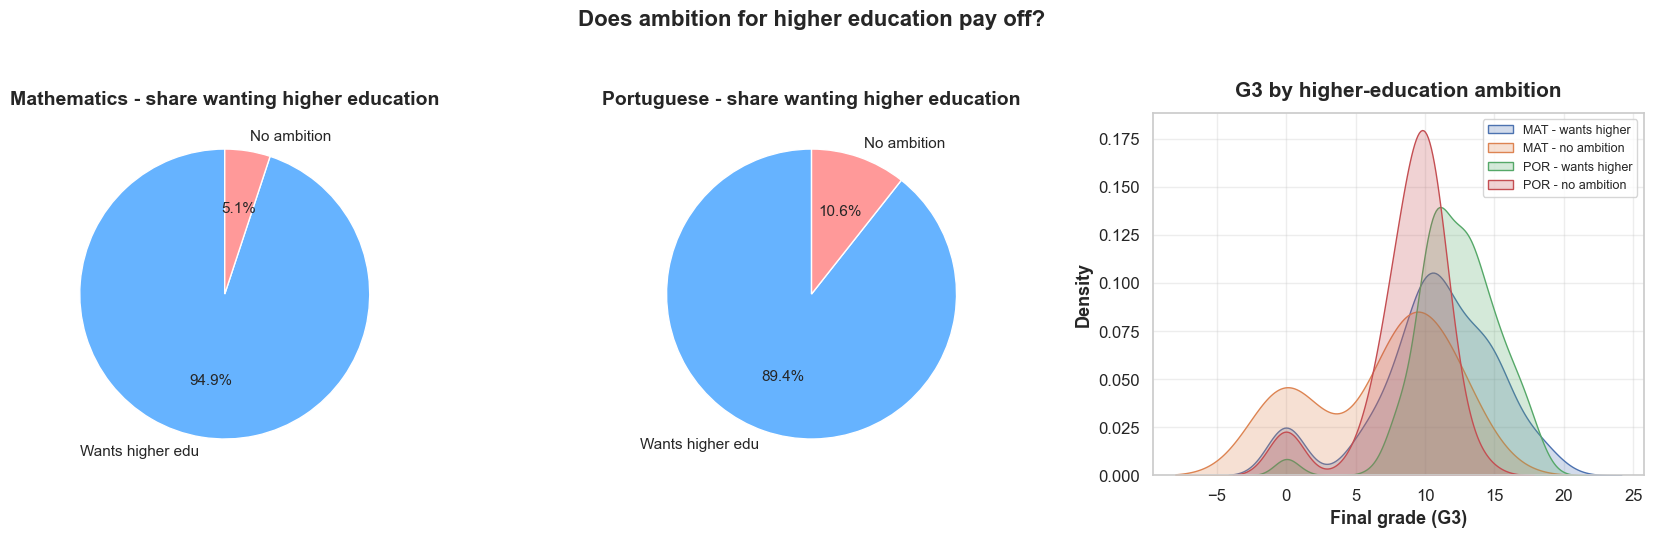

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
for ax, df, title in zip(axes[:2], (mat_df, por_df), ('Mathematics', 'Portuguese')):
    counts = df['higher'].value_counts()
    labels = ['Wants higher edu' if k == 'yes' else 'No ambition' for k in counts.index]
    ax.pie(counts.values, labels=labels, autopct='%1.1f%%',
           colors=['#66b3ff', '#ff9999'], startangle=90, textprops={'fontsize': 11})
    ax.set_title(f'{title} - share wanting higher education', fontsize=14, fontweight='bold')
ax = axes[2]
for df, name in ((mat_df, 'MAT'), (por_df, 'POR')):
    for h in ('yes', 'no'):
        sns.kdeplot(df.loc[df['higher'] == h, 'G3'], ax=ax, fill=True, alpha=0.25,
                    label=f'{name} - {"wants higher" if h == "yes" else "no ambition"}')
style_ax(ax, 'Final grade (G3)', 'Density', 'G3 by higher-education ambition')
ax.legend(fontsize=9)
fig.suptitle('Does ambition for higher education pay off?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q30. Does attending nursery school earlier give any lasting advantage?

A **box plot** compares the full grade distribution of students who did vs did not attend nursery school.

C:\Users\milon\AppData\Local\Temp\ipykernel_1600\3132336542.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='_n', y='G3', ax=ax, palette='PRGn', order=['No', 'Yes'], width=0.45)
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\3132336542.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='_n', y='G3', ax=ax, palette='PRGn', order=['No', 'Yes'], width=0.45)


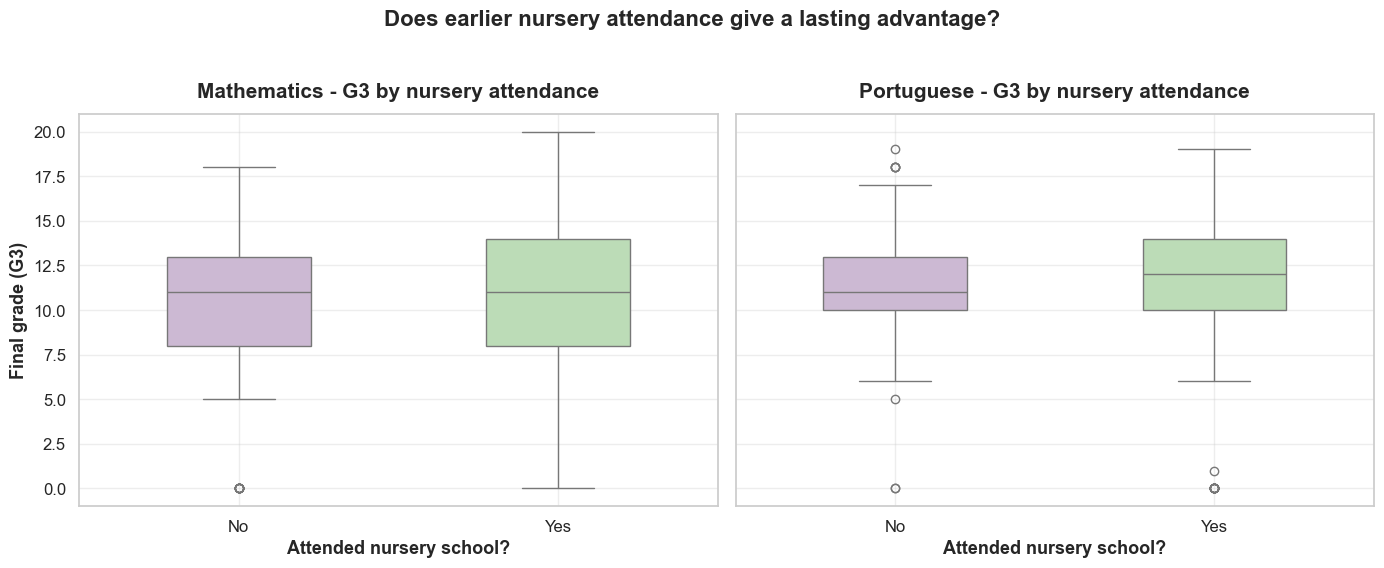

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    d = df.copy(); d['_n'] = d['nursery'].map({'no': 'No', 'yes': 'Yes'})
    sns.boxplot(data=d, x='_n', y='G3', ax=ax, palette='PRGn', order=['No', 'Yes'], width=0.45)
    style_ax(ax, 'Attended nursery school?', 'Final grade (G3)',
             f'{title} - G3 by nursery attendance')
fig.suptitle('Does earlier nursery attendance give a lasting advantage?',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()


### Q31. Do past failures cluster with absences, alcohol and going out (a 'risk profile')?

A **clustered heatmap (clustermap)** of the Spearman correlations among the risk features reveals natural groupings, and a **line plot** confirms that mean absences rise with the number of past failures.

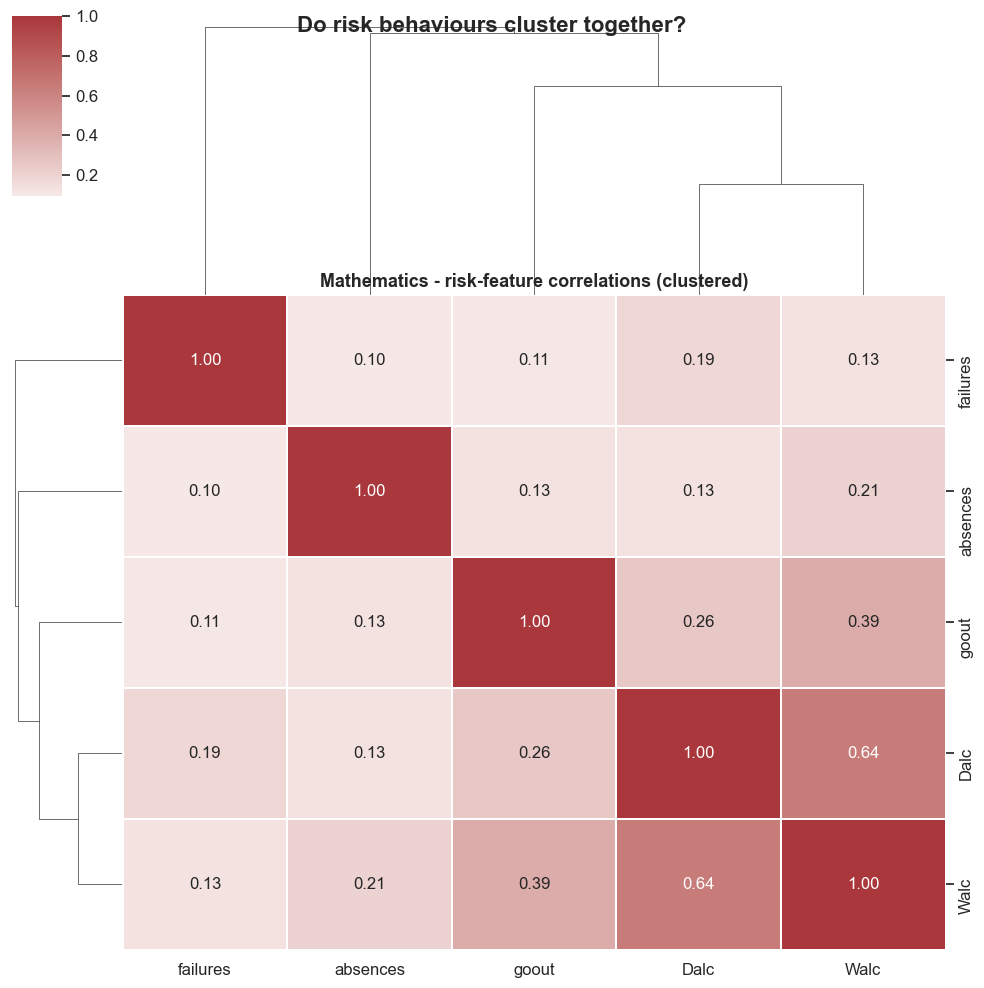

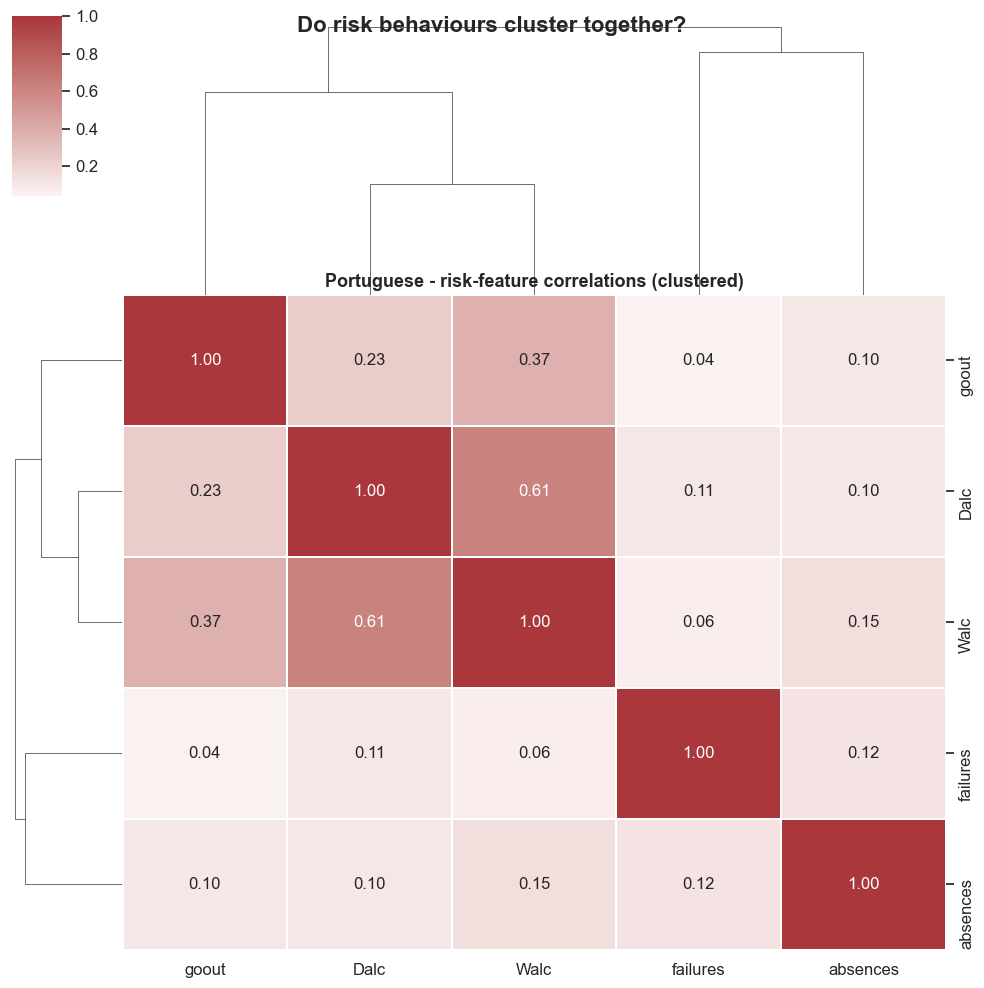

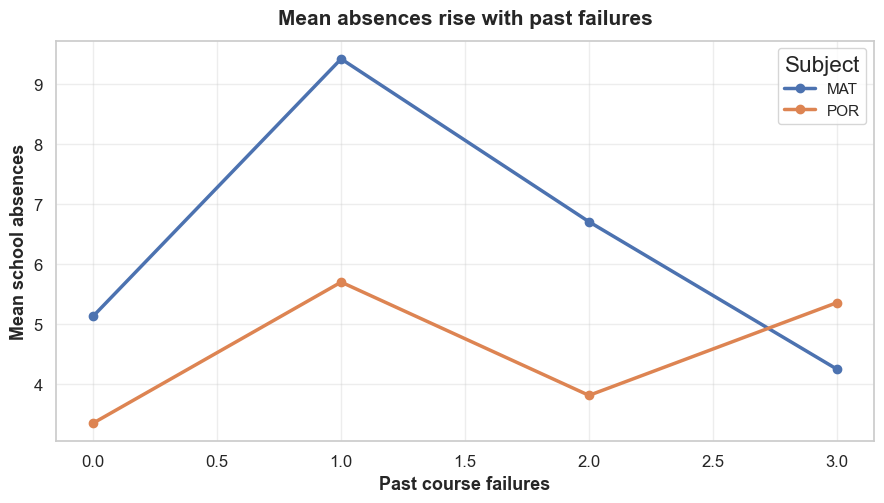

In [50]:
risk_feats = ['failures', 'absences', 'Dalc', 'Walc', 'goout']
for df, title in ((mat_df, 'Mathematics'), (por_df, 'Portuguese')):
    corr = df[risk_feats].corr(method='spearman')
    g = sns.clustermap(corr, annot=True, fmt='.2f', cmap='vlag', center=0,
                       dendrogram_ratio=(0.12, 0.3), linewidths=1.2)
    g.ax_heatmap.set_title(f'{title} - risk-feature correlations (clustered)',
                           fontsize=13, fontweight='bold')
    g.figure.suptitle('Do risk behaviours cluster together?',
                      fontsize=16, fontweight='bold', y=0.98)
    plt.show()

fig, ax = plt.subplots(figsize=(9, 5.2))
for df, name in ((mat_df, 'MAT'), (por_df, 'POR')):
    grp = df.groupby('failures')['absences'].mean()
    ax.plot(grp.index, grp.values, marker='o', lw=2.5, label=name)
style_ax(ax, 'Past course failures', 'Mean school absences',
         'Mean absences rise with past failures')
ax.legend(title='Subject'); fig.tight_layout(); plt.show()


### Q32. How different are the two subject cohorts on their background features?

A **diverging bar chart** visualises the z-tested difference between the Mathematics and Portuguese cohorts for each background feature (red = higher in Mathematics).

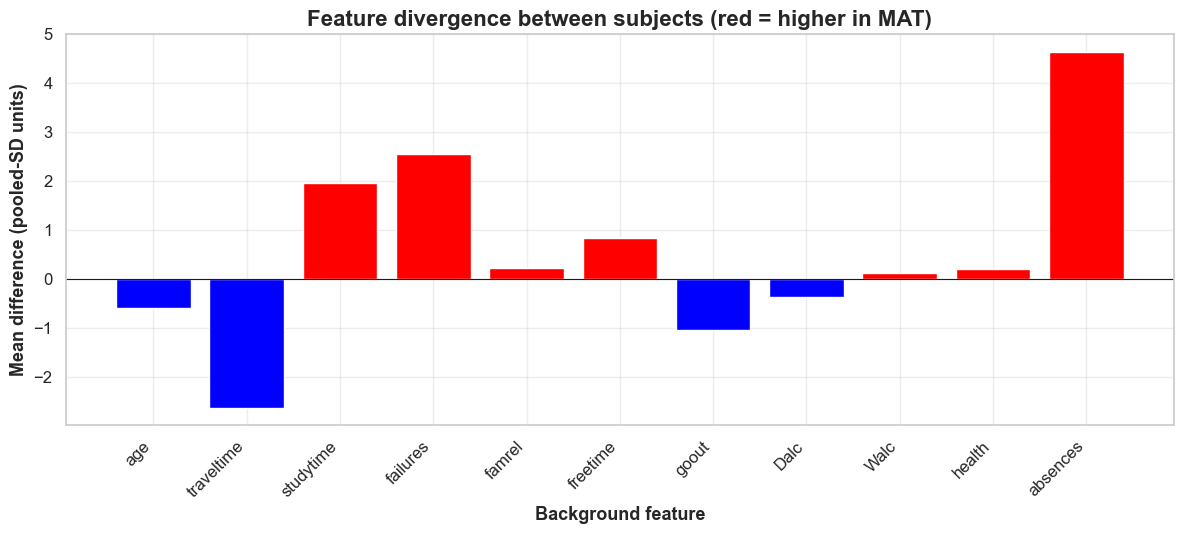

In [51]:
feats32 = ['age', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime',
           'goout', 'Dalc', 'Walc', 'health', 'absences']
feats32 = [f for f in feats32 if f in mat_df.columns]
m_mat = mat_df[feats32].mean(); s_mat = mat_df[feats32].std()
m_por = por_df[feats32].mean(); s_por = por_df[feats32].std()
z = (m_mat - m_por) / ((s_mat ** 2 / len(mat_df) + s_por ** 2 / len(por_df)) ** 0.5)

plt.figure(figsize=(12, 5.5))
colors = ['red' if v > 0 else 'blue' for v in z.values]
plt.bar(z.index, z.values, color=colors, edgecolor='white')
plt.axhline(0, color='k', lw=0.8)
plt.title('Feature divergence between subjects (red = higher in MAT)',
          fontsize=16, fontweight='bold')
plt.xlabel('Background feature', fontsize=13, fontweight='bold')
plt.ylabel('Mean difference (pooled-SD units)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.35); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()


### Q33. Combined demographics: which group (sex x address) needs the most support?

A **boxen plot** per gender-residence subgroup shows the distribution, and a **line plot** tracks the mean grade of each subgroup, side-by-side for the two subjects.

C:\Users\milon\AppData\Local\Temp\ipykernel_1600\2774406531.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=d, x='subgroup', y='G3', ax=ax, palette='YlGnBu', order=order)
C:\Users\milon\AppData\Local\Temp\ipykernel_1600\2774406531.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=d, x='subgroup', y='G3', ax=ax, palette='YlGnBu', order=order)


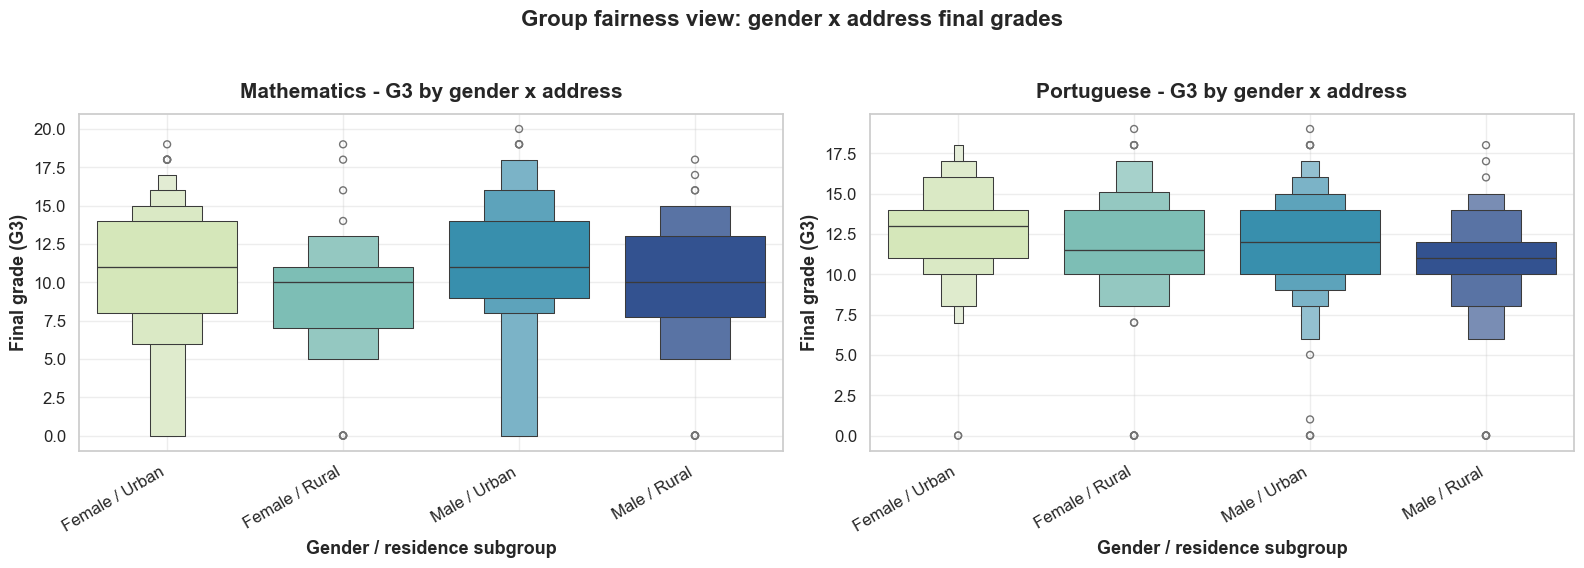

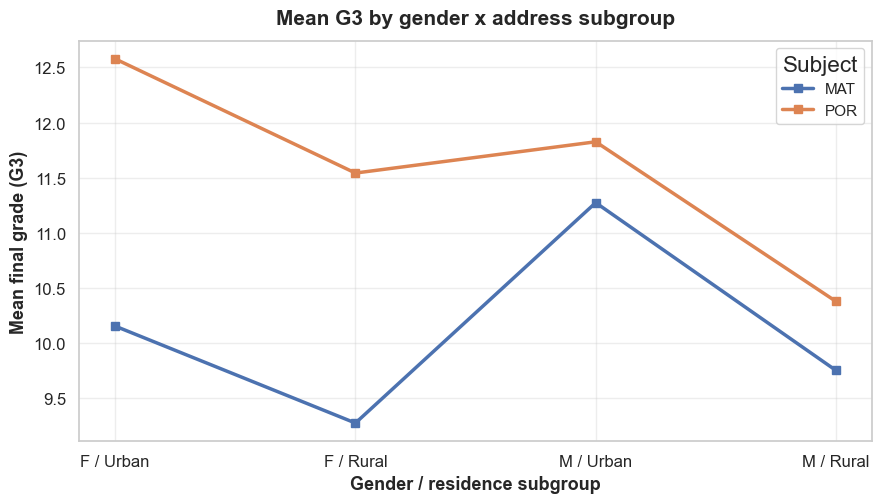

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    d = df.copy()
    d['subgroup'] = d['sex'].map({'F': 'Female', 'M': 'Male'}) + ' / ' + \
                    d['address'].map({'U': 'Urban', 'R': 'Rural'})
    order = ['Female / Urban', 'Female / Rural', 'Male / Urban', 'Male / Rural']
    sns.boxenplot(data=d, x='subgroup', y='G3', ax=ax, palette='YlGnBu', order=order)
    style_ax(ax, 'Gender / residence subgroup', 'Final grade (G3)',
             f'{title} - G3 by gender x address', rot_xticks=30)
fig.suptitle('Group fairness view: gender x address final grades',
             fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 5.2))
labels = ['F / Urban', 'F / Rural', 'M / Urban', 'M / Rural']
for df, name in ((mat_df, 'MAT'), (por_df, 'POR')):
    vals = [df.loc[(df.sex == s) & (df.address == a), 'G3'].mean()
            for s, a in [('F', 'U'), ('F', 'R'), ('M', 'U'), ('M', 'R')]]
    ax.plot(labels, vals, marker='s', lw=2.5, label=name)
style_ax(ax, 'Gender / residence subgroup', 'Mean final grade (G3)',
         'Mean G3 by gender x address subgroup')
ax.legend(title='Subject'); fig.tight_layout(); plt.show()


### Q34. Overall summary: which single features carry the most signal about G3?

A **point plot** (dot chart) of the Spearman correlation of every numeric feature with the final grade, one point per subject.

C:\Users\milon\AppData\Local\Temp\ipykernel_1600\241775215.py:11: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=res, x='feature', y='spearman', hue='dataset', errorbar=None,


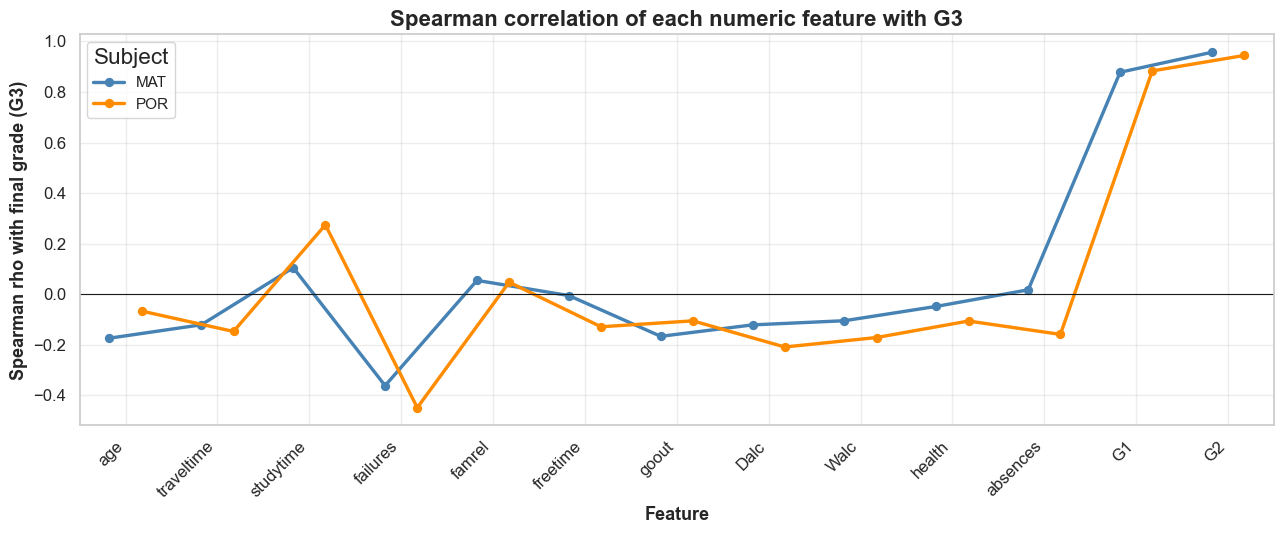

dataset       MAT    POR
feature                 
Dalc       -0.121 -0.208
G1          0.878  0.883
G2          0.957  0.944
Walc       -0.104 -0.171
absences    0.018 -0.159
age        -0.173 -0.066
failures   -0.361 -0.448
famrel      0.055  0.048
freetime   -0.005 -0.128
goout      -0.166 -0.105
health     -0.048 -0.106
studytime   0.105  0.275
traveltime -0.121 -0.147


In [53]:
from scipy.stats import spearmanr
num_cols = ['age', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime',
            'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
rows = []
for name, df in (('MAT', mat_df), ('POR', por_df)):
    for c in num_cols:
        rho, _ = spearmanr(df[c], df['G3'])
        rows.append({'feature': c, 'dataset': name, 'spearman': rho})
res = pd.DataFrame(rows)
plt.figure(figsize=(13, 5.5))
sns.pointplot(data=res, x='feature', y='spearman', hue='dataset', errorbar=None,
              palette=['steelblue', 'darkorange'], dodge=0.35, markers='o', scale=0.9)
plt.axhline(0, color='k', lw=0.8)
plt.title('Spearman correlation of each numeric feature with G3',
          fontsize=16, fontweight='bold')
plt.xlabel('Feature', fontsize=13, fontweight='bold')
plt.ylabel('Spearman rho with final grade (G3)', fontsize=13, fontweight='bold')
plt.legend(title='Subject'); plt.grid(True, alpha=0.35)
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

print(res.pivot(index='feature', columns='dataset', values='spearman').round(3))


high-dimensional views of the support effect (interactive Plotly)

Combining both subjects, these interactive figures visualise how combinations of family and school support relate to median grades and pass rates.

In [54]:
combo = pd.concat([
    mat_df.assign(subject='Math'),
    por_df.assign(subject='Portuguese')
], ignore_index=True)
combo['result'] = np.where(combo['G3'] >= 10, 'Pass', 'Fail')
combo['result_num'] = (combo['G3'] >= 10).astype(int)
combo.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Dalc,Walc,health,absences,G1,G2,G3,subject,result,result_num
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,1,1,3,6,5,6,6,Math,Fail,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,1,1,3,4,5,5,6,Math,Fail,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,3,3,10,7,8,10,Math,Pass,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,1,1,5,2,15,14,15,Math,Pass,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,1,2,5,4,6,10,10,Math,Pass,1


In [55]:
path_df = combo[['subject', 'famsup', 'schoolsup', 'higher', 'result', 'result_num']].copy()
fig = px.parallel_categories(
    path_df,
    dimensions=['subject', 'famsup', 'schoolsup', 'higher', 'result'],
    color='result_num',
    color_continuous_scale=['#EF553B', '#00CC96'],
    labels={'subject': 'Subject', 'famsup': 'Family supp',
            'schoolsup': 'School supp', 'higher': 'Wants higher edu',
            'result': 'Result'},
    title='High-Dimensional Flow: Which student pathways lead to a Pass?')
fig.update_layout(margin=dict(l=160, r=100, t=90, b=60),
                  coloraxis_showscale=False, template='plotly_dark')
fig.show()


In [56]:
tree_df = (combo.groupby(['famsup', 'schoolsup', 'result'], as_index=False)
           .agg(count=('G3', 'size'), med_grade=('G3', 'median')))
fig = px.treemap(
    tree_df,
    path=['famsup', 'schoolsup', 'result'],
    values='count',
    color='med_grade',
    color_continuous_scale='RdYlGn',
    range_color=(combo['G3'].quantile(0.05), combo['G3'].quantile(0.95)),
    title='Hierarchical View: Family & School Support vs Median Final Grade',
    labels={'famsup': 'Family support', 'schoolsup': 'School support',
            'result': 'Result', 'med_grade': 'Median G3'})
fig.update_layout(margin=dict(t=55, l=25, r=25, b=25))
fig.show()


In [57]:
sun_df = (combo.groupby(['famsup', 'schoolsup'], as_index=False)
            .agg(count=('G3', 'size'), pass_rate=('result_num', 'mean')))
sun_df['pass_rate'] = (sun_df['pass_rate'] * 100).round(1)
fig = px.sunburst(
    sun_df,
    path=['famsup', 'schoolsup'],
    values='count',
    color='pass_rate',
    color_continuous_scale='RdYlGn',
    range_color=(sun_df['pass_rate'].min() - 2, sun_df['pass_rate'].max() + 2),
    title='The Support Effect: Pass Rate (%) by Family vs School Support',
    labels={'famsup': 'Family support', 'schoolsup': 'School support',
            'pass_rate': 'Pass rate (%)'})
fig.update_layout(coloraxis_colorbar_title='Pass rate (%)')
fig.show()


In [ ]:
combo['support_combo'] = ('fam=' + combo['famsup'] + ', sch=' + combo['schoolsup'])
bar_df = combo.groupby(['subject', 'support_combo'], as_index=False)['G3'].mean()
bar_df['G3'] = bar_df['G3'].round(2)
fig = px.bar(
    bar_df, x='subject', y='G3', color='support_combo', barmode='group',
    color_discrete_map={'fam=no, sch=no': '#B0BEC5',
                        'fam=yes, sch=no': '#00CC96',
                        'fam=no, sch=yes': '#636EFA',
                        'fam=yes, sch=yes': '#EF553B'},
    title='Mean final grade by support combination (Math vs Portuguese)',
    labels={'subject': 'Subject', 'G3': 'Mean final grade (G3)',
            'support_combo': 'Support combination'})
fig.update_layout(template='plotly_white')
fig.show()


In [ ]:
support_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'internet', 'higher']
rows = []
for sub_df, sub_name in ((mat_df.copy(), 'Math'), (por_df.copy(), 'Portuguese')):
    sub_df['result_num'] = (sub_df['G3'] >= 10).astype(int)
    for f in support_cols:
        lift = sub_df[sub_df[f] == 'yes']['G3'].mean() - sub_df[sub_df[f] == 'no']['G3'].mean()
        rows.append({'resource': f, 'subject': sub_name, 'G3 lift': round(lift, 2)})
uplift = pd.DataFrame(rows)
fig = px.bar(uplift, y='resource', x='G3 lift', color='subject',
             barmode='group', orientation='h',
             title='Which school/home resource gives the biggest grade boost?',
             labels={'resource': 'Resource', 'G3 lift': 'Mean G3 lift (yes - no)',
                     'subject': 'Subject'})
fig.add_vline(x=0, line_width=1, line_color='black', line_dash='dot')
fig.update_layout(template='plotly_white')
fig.show()


## Interpretation: which support matters more?

- **`schoolsup` is a risk-signal, not a cure.** Students with school support score *lower* on average (MAT ~1.1 pts, POR ~0.7 pts) **because support is aimed at at-risk students** - the parallel-categories plot shows narrow, red-heavy `schoolsup=yes` flows.
- **`famsup` is the more reliable (neutral-to-positive) support.** Across both subjects, family support coincides with equal-or-slightly-higher grades and pass rates; the grouped bar + sunburst show `fam=yes, sch=no` is the strongest, healthiest combination.
- **The real levers are ambition and connectivity:** `higher` lifts G3 by ~3.5-3.8 pts and pass rate by ~30-35 pts; home `internet` adds ~1.1-1.2 pts. Both dwarf `famsup` and `schoolsup`.
- **Fair-model take-away:** treat `schoolsup` as an *at-risk / need* indicator, and lean on `higher`, `studytime`, prior grades and `internet` for signal.

# Key takeaways from the EDA

- **Prior grades dominate:** `G2` (and `G1`) are by far the strongest predictors of `G3`; behavioural features add only marginal linear signal (Q11, Q34).
- **Fairness-relevant gaps exist:** urban vs rural, school (GP vs MS), parental education, and internet access all show grade differences a model could encode as bias (Q1, Q2, Q9, Q14, Q33).
- **Gender:** boys outperform girls in Mathematics but the gap shrinks/reverses in Portuguese (Q6, Q33).
- **Past failures are the strongest behavioural red flag**, and they cluster with more absences and higher alcohol use (Q4, Q31).
- **Lifestyle effects are modest but consistent:** more going out, weekday/weekend alcohol and longer commutes correlate with slightly lower grades; Dalc and Walc are strongly correlated (rho ~0.6, Q3, Q21, Q22).
- **Grade trajectories:** most students improve from G1 to G3 in Portuguese while Mathematics is stagnant/declining; students receiving school support improve slightly more in Math (Q23, Q26).
- **Data-quality flag:** a noticeable share of students has `G3 = 0`, which likely means 'dropped out / not evaluated' rather than a true score - handle these separately before modelling (Q12, Q28).
- **Interactions:** high study time cannot fully compensate for heavy socialising/alcohol, and good family relationships appear to soften the alcohol effect (Q24, Q25).